# train an agent to play Ms. Pac-Man

**Choose three numbers. Run the notebook. Watch what the agent learns.**

The agent sees the game screen, chooses a move, and receives a reward from the game.
A neural network learns a value for each move through trial and error.

1. Open this notebook in Jupyter, VS Code, or Google Colab. In Colab, select **Runtime → Change runtime type → T4 GPU** if available.
2. Choose your three settings in the next cell.
3. Choose **Run All** (Colab: **Runtime → Run all**). Setup runs automatically. Local gameplay samples open above VS Code in a floating player at **4× speed**; a copy also appears inline.
4. Compare the five before/after scores and save your results.

If using Claude Code or Codex, ask it to run this notebook. The code tells it to ask you for your three choices before training.

A short run checks that everything works. Learning useful Atari behavior can take much longer; more episodes do not guarantee better play.

## 1. your three choices

| Setting | Meaning | Starting point |
|---|---|---|
| **Exploration** | Fraction of training moves chosen randomly. `0.20` means 20%. | `0.20` |
| **Episodes** | How many games to train on. Each game ends at game over or a fixed time limit. | `100` |
| **Learning rate** | How much the network changes at each update. | `0.0001` |

Change only the three numbers below. Try `5` episodes for a first check, then a longer run.
For this experiment, exploration stays **constant** so its meaning is easy to compare across runs.
The short replay warm-up uses random moves before learning starts.

In [1]:
# The student authorized a stronger experiment toward consistent 3,000+ scores.
# Choices and extensions are explained before execution in experiment_plan.md.
EXPLORATION = 0.10
EPISODES = 2500  # Additional complete games, after inherited training.
LEARNING_RATE = 0.00005


### check the choices

These checks catch typos before a long experiment starts. They do not change your settings.

In [2]:
import math
assert (
    isinstance(EXPLORATION, (int, float))
    and not isinstance(EXPLORATION, bool)
    and math.isfinite(EXPLORATION) and 0 <= EXPLORATION <= 1
), "Exploration must be between 0 and 1."
assert (
    isinstance(EPISODES, int) and not isinstance(EPISODES, bool) and EPISODES > 0
), "Episodes must be a positive whole number."
assert (
    isinstance(LEARNING_RATE, (int, float))
    and not isinstance(LEARNING_RATE, bool)
    and math.isfinite(LEARNING_RATE) and 0 < LEARNING_RATE <= 1
), "Learning rate must be greater than 0 and at most 1."
print(f"Your experiment: {EXPLORATION:.0%} exploration, {EPISODES} episodes, learning rate {LEARNING_RATE:g}.")

Your experiment: 10% exploration, 2500 episodes, learning rate 5e-05.


## 2. automatic setup

Run this once per fresh session. It installs missing packages into the notebook's Python environment.
Python 3.11–3.13 is recommended. No separate game download is needed. For local popup playback, keep `pacman_player.py` next to this notebook and use a Python kernel with Tk (the local `py313` kernel supports it). Colab and machines without a desktop keep the fast inline preview.
If a package was already imported before an upgrade, restart the kernel and choose Run All again.

In [3]:
%pip -q install "torch>=2.6,<3" "gymnasium==1.3.0" "ale-py==0.11.2" "opencv-python-headless==4.14.0.94" "numpy>=2,<3" "matplotlib>=3.9,<4" "Pillow>=10,<13"


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: /Users/sebastianbardacostaartagaveytia/Documents/ChatGPT/Class 3/.venv/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


### load the tools

Gymnasium runs the game, PyTorch learns from its screens, and Pillow saves gameplay. This cell also prints the actual Python and package versions, so runs can be compared.

In [4]:
import csv
import json
import platform
import random
import shutil
import time
from collections import deque
from datetime import datetime
from pathlib import Path
from importlib.metadata import version

import ale_py
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from PIL import Image as PILImage
from IPython.display import Image, FileLink, display

gym.register_envs(ale_py)
# Keep CPU thread overhead manageable on laptops.
torch.set_num_threads(min(4, torch.get_num_threads()))


VERSIONS = {p: version(p) for p in ['torch', 'gymnasium', 'ale-py', 'opencv-python-headless', 'numpy', 'matplotlib', 'Pillow']}
print(f"Python {platform.python_version()} | {platform.platform()}")
print(VERSIONS)

Python 3.12.14 | macOS-26.6.2-arm64-arm-64bit
{'torch': '2.14.0', 'gymnasium': '1.3.0', 'ale-py': '0.11.2', 'opencv-python-headless': '4.14.0.94', 'numpy': '2.5.3', 'matplotlib': '3.11.2', 'Pillow': '12.3.0'}


### Training extensions for this experiment

Keep the classroom environment and evaluation unchanged. Warm-start the previously
trained scaled-reward network, use three-step Double DQN with prioritized replay,
and subtract 0.5 training reward for each lost life. Four training environments
share one learner and batch action predictions to reduce hardware overhead.
The experiment has a two-hour wall-clock training cap; all actual work is recorded.


In [5]:
SEED = 42
MAX_STEPS = 3000
FRAME_SKIP = 4
REPLAY_CAPACITY = 50000
BATCH_SIZE = 32
WARMUP_STEPS = 1000       # First 1,000 new decisions remain random.
LEARNING_STARTS = 10000  # Fill fresh replay before modifying inherited weights.
TRAIN_EVERY = 4
TARGET_EVERY = 1000
GAMMA = 0.99
DEMO_EVERY = 25
EVAL_SEEDS = [101, 202, 303, 404, 505]
EVAL_EXPLORATION = 0.05
TRAINING_TIME_LIMIT_SECONDS = 2 * 60 * 60
TRAINING_REWARD_SCALE = 0.01
LIFE_LOSS_PENALTY = 0.5
N_STEP = 3
NUM_TRAIN_ENVS = 4
PRIORITY_ALPHA = 0.5
PRIORITY_BETA_START = 0.4
PRIORITY_BETA_DECISIONS = 2000000
WARM_START_RUN = "20260920_152728_434799"
WARM_START_EPISODES = 1069
WARM_START_DECISIONS = 744500
WARM_START_UPDATES = 185875
WARM_START_SHA256 = "b181f817b3f37a254addca3edb2da8ddb68abf41a3fe7fc64014fff4f0d0869c"
WARM_START_URL = "https://github.com/sbardacosta-code/class-3-pacman-dqn/releases/download/warmstart-scaled-1069/scaled-1069.pt"

VALIDATION_SEEDS = list(range(20001, 20011))
VALIDATION_EVERY = 250


### faster sample playback

Samples play **4× faster**: 20 seconds of game time takes about five seconds to watch. We save every fourth preview frame and keep a normal display interval, avoiding tiny GIF delays that viewers often clamp. This only changes the recording and playback; every game decision still runs normally.

Local samples open automatically in an **always-on-top popup** with Pause, Replay, and a pin toggle. Each sample plays exactly twice and stops on its final frame. Replay starts two more plays. Closing the popup leaves training running. Set `SHOW_POPUPS = False` for inline playback only.

In [6]:
PREVIEW_SPEED = 4
PREVIEW_PLAYS = 2
SHOW_POPUPS = False  # Save every GIF inline without opening repeated desktop windows.
PREVIEW_SECONDS = 20
PREVIEW_STRIDE = PREVIEW_SPEED
PREVIEW_DECISIONS = round(PREVIEW_SECONDS * 60 / FRAME_SKIP)
PREVIEW_FRAME_MS = round(1000 * FRAME_SKIP / 60)


## 3. the game and the learning rule

The network sees **four grayscale 84 × 84 screens** so it can infer movement.
Its outputs are estimated future rewards for the available moves, not probabilities.

The agent keeps past experiences in a small replay memory. It samples them to update the network.
A second, slower-changing network supplies the learning target:

**target = reward + discounted value of the next screen**

At game over, there is no future reward. At a time limit, the game could have continued, so we keep the future-value term.
Learning uses rewards clipped to −1 through +1; every score you see is the **original game score**.
The implementation below is ready to use. You do not need to edit it.

### 3a. turn game screens into observations

Start Ms. Pac-Man, reduce each screen to 84 × 84 grayscale pixels, and stack four screens. A single image shows position; a short sequence also reveals movement. Reset starts with four copies of the new game screen.

In [7]:
def make_env():
    env = gym.make("ALE/MsPacman-v5", frameskip=1,
                   repeat_action_probability=0.25, render_mode="rgb_array")
    env = gym.wrappers.AtariPreprocessing(
        env, noop_max=30, frame_skip=FRAME_SKIP, screen_size=84,
        terminal_on_life_loss=False, grayscale_obs=True, scale_obs=False)
    env = gym.wrappers.FrameStackObservation(env, stack_size=4, padding_type="reset")
    return gym.wrappers.TimeLimit(env, max_episode_steps=MAX_STEPS)

### 3b. estimate the value of each move

The convolution layers look for patterns in the screens. The final layer produces one number per move: its estimated future reward. `forward` scales pixel values from 0–255 to 0–1 before using them.

In [8]:
class DQN(nn.Module):
    def __init__(self, n_actions):
        super().__init__()
        # Read visual patterns, then produce one value per available move.
        self.layers = nn.Sequential(
            nn.Conv2d(4, 32, 8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2), nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=1), nn.ReLU(),
            nn.Flatten(), nn.Linear(3136, 512), nn.ReLU(),
            nn.Linear(512, n_actions))

    def forward(self, screens):
        return self.layers(screens.float() / 255.0)

### 3c. prioritized memory and three-step returns

Each transition stores both actual four-screen stacks. For up to three decisions,
accumulate discounted training rewards and bootstrap from the correct future stack.
True game over suppresses future value. A time limit flushes the pending sequence
but retains bootstrapping; no sequence crosses a reset. Losing a life adds the
explicit penalty but does not itself terminate the game or suppress future value.

Replay favors larger prediction errors, with importance weights correcting the
sampling bias. Independent queues keep experiences from different games separate.


In [9]:
"""NumPy prioritized n-step replay with independent queues for vectorized games.

Rewards passed to add() must already have their intended scaling/shaping. True
termination suppresses bootstrapping; a time limit flushes its queue but retains
bootstrapping. Observations and the actual final next-observations are stored in
full, so frame stacks remain correct for multi-step transitions.

state_dict() includes NumPy arrays and RNG state. When using torch serialization,
load these snapshots only from trusted local files with weights_only=False.
"""

from collections import deque
from copy import deepcopy

import numpy as np


class PrioritizedNStepReplay:
    def __init__(self, capacity, n_step=3, gamma=0.99, alpha=0.5, seed=43,
                 n_envs=4, observation_shape=(4, 84, 84)):
        for name, value in (("capacity", capacity), ("n_step", n_step), ("n_envs", n_envs)):
            if isinstance(value, bool) or not isinstance(value, (int, np.integer)) or value < 1:
                raise ValueError(f"{name} must be a positive integer")
        if not np.isfinite(gamma) or not 0 <= gamma <= 1:
            raise ValueError("gamma must be finite and between zero and one")
        if not np.isfinite(alpha) or not 0 <= alpha <= 1:
            raise ValueError("alpha must be finite and between zero and one")
        if not observation_shape or any(not isinstance(x, (int, np.integer)) or x < 1
                                        for x in observation_shape):
            raise ValueError("observation_shape must contain positive integer dimensions")
        self.capacity = int(capacity)
        self.n_step = int(n_step)
        self.gamma = float(gamma)
        self.alpha = float(alpha)
        self.n_envs = int(n_envs)
        self.observation_shape = tuple(int(x) for x in observation_shape)
        self.epsilon = 1e-6
        self.rng = np.random.default_rng(seed)
        self.obs = np.empty((self.capacity, *self.observation_shape), dtype=np.uint8)
        self.next_obs = np.empty_like(self.obs)
        self.actions = np.empty(self.capacity, dtype=np.int64)
        self.rewards = np.empty(self.capacity, dtype=np.float32)
        self.discounts = np.empty(self.capacity, dtype=np.float32)
        self.horizons = np.empty(self.capacity, dtype=np.int32)
        self.priorities = np.empty(self.capacity, dtype=np.float64)
        self._leaf_count = 1 << (self.capacity - 1).bit_length()
        self._sum_tree = np.zeros(2 * self._leaf_count, dtype=np.float64)
        self._min_tree = np.full(2 * self._leaf_count, np.inf, dtype=np.float64)
        self.pending = [deque() for _ in range(self.n_envs)]
        self.position = 0
        self.size = 0
        self.max_priority = 1.0

    def __len__(self):
        return self.size

    def _observation(self, value):
        array = np.asarray(value)
        if array.shape != self.observation_shape or array.dtype != np.uint8:
            raise ValueError(f"Expected uint8 observation shape {self.observation_shape}")
        return array.copy()

    def _transition(self, obs, action, reward, next_obs, terminated, truncated):
        if isinstance(action, bool) or not isinstance(action, (int, np.integer)):
            raise ValueError("action must be an integer")
        reward = float(reward)
        if not np.isfinite(reward):
            raise ValueError("reward must be finite")
        return (self._observation(obs), int(action), reward,
                self._observation(next_obs), bool(terminated), bool(truncated))

    def add(self, env_id, obs, action, reward, next_obs, terminated, truncated):
        if not isinstance(env_id, (int, np.integer)) or not 0 <= env_id < self.n_envs:
            raise ValueError("env_id is outside the configured environment range")
        transition = self._transition(obs, action, reward, next_obs, terminated, truncated)
        queue = self.pending[env_id]
        queue.append(transition)
        if len(queue) >= self.n_step:
            self._emit(queue)
            queue.popleft()
        if terminated or truncated:
            while queue:
                self._emit(queue)
                queue.popleft()

    def _emit(self, queue):
        total = 0.0
        factor = 1.0
        horizon = 0
        for transition in queue:
            total += factor * transition[2]
            horizon += 1
            factor *= self.gamma
            if transition[4] or transition[5] or horizon == self.n_step:
                break
        if not np.isfinite(total) or abs(total) > np.finfo(np.float32).max:
            raise ValueError("n-step return cannot be represented as a finite float32")
        index = self.position
        self.obs[index] = queue[0][0]
        self.actions[index] = queue[0][1]
        self.rewards[index] = total
        self.next_obs[index] = transition[3]
        self.discounts[index] = 0.0 if transition[4] else factor
        self.horizons[index] = horizon
        self.priorities[index] = self.max_priority
        self._set_leaves(np.array([index]), np.array([self.max_priority ** self.alpha]))
        self.position = (index + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def _set_leaves(self, indices, masses):
        nodes = np.asarray(indices, dtype=np.int64) + self._leaf_count
        self._sum_tree[nodes] = masses
        self._min_tree[nodes] = masses
        nodes = np.unique(nodes // 2)
        while nodes.size and nodes[0] > 0:
            self._sum_tree[nodes] = self._sum_tree[2 * nodes] + self._sum_tree[2 * nodes + 1]
            self._min_tree[nodes] = np.minimum(self._min_tree[2 * nodes],
                                              self._min_tree[2 * nodes + 1])
            nodes = np.unique(nodes // 2)

    def sample(self, batch_size, beta):
        if self.size == 0:
            raise ValueError("Cannot sample an empty replay")
        if not isinstance(batch_size, (int, np.integer)) or batch_size < 1:
            raise ValueError("batch_size must be a positive integer")
        if not np.isfinite(beta) or not 0 <= beta <= 1:
            raise ValueError("beta must be finite and between zero and one")
        total = self._sum_tree[1]
        if not np.isfinite(total) or total <= 0:
            raise ValueError("Invalid total replay priority")
        # One independently jittered sample from each equal-mass stratum.
        values = (np.arange(batch_size) + self.rng.random(batch_size)) * (total / batch_size)
        values = np.minimum(values, np.nextafter(total, 0.0))
        nodes = np.ones(batch_size, dtype=np.int64)
        for _ in range(self._leaf_count.bit_length() - 1):
            left = 2 * nodes
            left_mass = self._sum_tree[left]
            take_right = values >= left_mass
            values -= np.where(take_right, left_mass, 0.0)
            nodes = left + take_right
        indices = nodes - self._leaf_count
        if np.any(indices >= self.size):
            raise RuntimeError("Priority tree selected an unfilled replay slot")
        # Globally normalized (N*p)^-beta, using the minimum active probability.
        # N and total cancel in the ratio; log space avoids intermediate overflow.
        weights = np.exp(-float(beta) * (np.log(self._sum_tree[nodes]) -
                                         np.log(self._min_tree[1]))).astype(np.float32)
        return {"obs": self.obs[indices], "actions": self.actions[indices],
                "rewards": self.rewards[indices], "next_obs": self.next_obs[indices],
                "discounts": self.discounts[indices], "weights": weights,
                "indices": indices}

    def update_priorities(self, indices, td_errors):
        indices = np.asarray(indices)
        errors = np.asarray(td_errors, dtype=np.float64)
        if indices.ndim != 1 or errors.ndim != 1 or indices.shape != errors.shape:
            raise ValueError("indices and td_errors must be equal-length one-dimensional arrays")
        if not np.issubdtype(indices.dtype, np.integer):
            raise ValueError("indices must be integers")
        if not indices.size:
            return
        if np.any(indices < 0) or np.any(indices >= self.size) or not np.all(np.isfinite(errors)):
            raise ValueError("Invalid replay indices or non-finite TD errors")
        unique, inverse = np.unique(indices, return_inverse=True)
        priorities = np.zeros(len(unique), dtype=np.float64)
        np.maximum.at(priorities, inverse, np.abs(errors) + self.epsilon)
        masses = priorities ** self.alpha
        other_total = self._sum_tree[1] - self._sum_tree[unique + self._leaf_count].sum()
        if not np.all(np.isfinite(masses)) or not np.isfinite(other_total + masses.sum()):
            raise ValueError("Updated priorities would overflow the priority tree")
        self.priorities[unique] = priorities
        self.max_priority = max(self.max_priority, float(priorities.max()))
        self._set_leaves(unique, masses)

    def state_dict(self, *, copy_arrays=True):
        """Return a complete snapshot, including pending tails and sampler RNG.

        copy_arrays=False avoids duplicating replay storage, but its returned
        array views must be serialized synchronously before collecting more data.
        Uninitialized storage beyond size is never exported.
        """
        arrays = {}
        for name in ("obs", "next_obs", "actions", "rewards", "discounts", "horizons", "priorities"):
            value = getattr(self, name)[:self.size]
            arrays[name] = value.copy() if copy_arrays else value
        return {"schema_version": 1,
                "config": {"capacity": self.capacity, "n_step": self.n_step,
                           "gamma": self.gamma, "alpha": self.alpha,
                           "n_envs": self.n_envs, "observation_shape": self.observation_shape,
                           "epsilon": self.epsilon},
                "size": self.size, "position": self.position,
                "max_priority": self.max_priority, "arrays": arrays,
                "pending": deepcopy([list(queue) for queue in self.pending]),
                "rng_state": deepcopy(self.rng.bit_generator.state)}

    def load_state_dict(self, state):
        expected = {"capacity": self.capacity, "n_step": self.n_step,
                    "gamma": self.gamma, "alpha": self.alpha,
                    "n_envs": self.n_envs, "observation_shape": self.observation_shape,
                    "epsilon": self.epsilon}
        if state.get("schema_version") != 1 or state.get("config") != expected:
            raise ValueError("Replay snapshot configuration does not match this replay")
        size, position = int(state["size"]), int(state["position"])
        if not 0 <= size <= self.capacity or not 0 <= position < self.capacity:
            raise ValueError("Invalid replay snapshot size or position")
        if size < self.capacity and position != size:
            raise ValueError("Partially filled replay snapshot has an invalid position")
        arrays = {}
        for name in ("obs", "next_obs", "actions", "rewards", "discounts", "horizons", "priorities"):
            value = np.asarray(state["arrays"][name])
            destination = getattr(self, name)
            if value.shape != (size, *destination.shape[1:]) or value.dtype != destination.dtype:
                raise ValueError(f"Invalid snapshot array {name}")
            arrays[name] = value
        if not all(np.all(np.isfinite(arrays[name])) for name in ("rewards", "discounts", "priorities")):
            raise ValueError("Non-finite replay snapshot values")
        if np.any(arrays["priorities"] <= 0) or np.any(arrays["horizons"] < 1) or np.any(arrays["horizons"] > self.n_step):
            raise ValueError("Invalid priorities or horizons in replay snapshot")
        if np.any(arrays["discounts"] < 0) or np.any(arrays["discounts"] > 1):
            raise ValueError("Invalid replay snapshot discounts")
        maximum = float(state["max_priority"])
        if not np.isfinite(maximum) or maximum <= 0 or (size and maximum < arrays["priorities"].max()):
            raise ValueError("Invalid maximum priority in replay snapshot")
        if len(state["pending"]) != self.n_envs:
            raise ValueError("Wrong number of pending environment queues")
        pending = []
        for queue in state["pending"]:
            if len(queue) >= self.n_step:
                raise ValueError("Unflushed n-step queue in replay snapshot")
            converted = deque(self._transition(*transition) for transition in queue)
            if any(transition[4] or transition[5] for transition in converted):
                raise ValueError("Pending snapshot queues must not cross episode boundaries")
            pending.append(converted)
        rng = np.random.default_rng()
        rng.bit_generator.state = deepcopy(state["rng_state"])
        masses = arrays["priorities"] ** self.alpha
        if not np.isfinite(masses.sum()):
            raise ValueError("Replay snapshot priorities overflow")
        for name, value in arrays.items():
            getattr(self, name)[:size] = value
        self.size, self.position, self.max_priority = size, position, maximum
        self.pending, self.rng = pending, rng
        self._sum_tree.fill(0.0)
        self._min_tree.fill(np.inf)
        self._sum_tree[self._leaf_count:self._leaf_count + size] = masses
        self._min_tree[self._leaf_count:self._leaf_count + size] = masses
        start = self._leaf_count // 2
        while start:
            nodes = np.arange(start, 2 * start)
            self._sum_tree[nodes] = self._sum_tree[2 * nodes] + self._sum_tree[2 * nodes + 1]
            self._min_tree[nodes] = np.minimum(self._min_tree[2 * nodes], self._min_tree[2 * nodes + 1])
            start //= 2


### 3d. choose a move

With probability `epsilon`, try a random move (**explore**). Otherwise choose the move with the highest predicted value (**exploit**). Choosing a move does not update the network.

In [10]:
@torch.no_grad()
def choose_action(model, obs, epsilon, rng, n_actions):
    if rng.random() < epsilon:
        return rng.randrange(n_actions)
    device = next(model.parameters()).device
    screens = torch.as_tensor(np.asarray(obs), device=device).unsqueeze(0)
    return int(model(screens).argmax(dim=1).item())

### 3e. learn from prioritized three-step experiences

Double DQN selects the next action with the online network and values it with the
target network. The target combines the discounted three-step reward with the
appropriate future value. Importance-weighted Huber loss trains the model, and
absolute prediction errors update replay priorities. Loss is not a gameplay score.


In [11]:
def learn(model, target, optimizer, batch):
    device = next(model.parameters()).device
    obs = torch.as_tensor(batch["obs"], device=device)
    next_obs = torch.as_tensor(batch["next_obs"], device=device)
    actions = torch.as_tensor(batch["actions"], device=device, dtype=torch.long)
    rewards = torch.as_tensor(batch["rewards"], device=device)
    discounts = torch.as_tensor(batch["discounts"], device=device)
    weights = torch.as_tensor(batch["weights"], device=device)
    values = model(obs).gather(1, actions[:, None]).squeeze(1)
    with torch.no_grad():
        next_actions = model(next_obs).argmax(dim=1, keepdim=True)
        next_values = target(next_obs).gather(1, next_actions).squeeze(1)
        targets = rewards + discounts * next_values
    td_errors = targets - values
    loss = (weights * nn.functional.smooth_l1_loss(values, targets, reduction="none")).mean()
    if not torch.isfinite(loss):
        raise RuntimeError("Non-finite loss; saving this failed run for inspection.")
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), 10.0, error_if_nonfinite=True)
    optimizer.step()
    return float(loss.item()), td_errors.detach().abs().cpu().numpy()


### 3f. select working hardware

Try CUDA, Apple MPS, then CPU. A real batch tests prediction, backward pass, and a weight update before we commit to that device.

In [12]:
def select_device(n_actions):
    candidates = []
    if torch.cuda.is_available():
        candidates.append("cuda")
    if torch.backends.mps.is_available():
        candidates.append("mps")
    candidates.append("cpu")
    for candidate in candidates:
        try:
            probe = DQN(n_actions).to(candidate)
            optimizer = torch.optim.Adam(probe.parameters(), lr=LEARNING_RATE)
            screens = np.zeros((BATCH_SIZE, 4, 84, 84), dtype=np.uint8)
            batch = {"obs": screens, "next_obs": screens,
                     "actions": np.zeros(BATCH_SIZE, dtype=np.int64),
                     "rewards": np.ones(BATCH_SIZE, dtype=np.float32),
                     "discounts": np.full(BATCH_SIZE, GAMMA ** N_STEP, dtype=np.float32),
                     "weights": np.ones(BATCH_SIZE, dtype=np.float32)}
            learn(probe, probe, optimizer, batch)
            print(f"Using {candidate.upper()}; prioritized three-step training batch passed.")
            return torch.device(candidate)
        except RuntimeError as error:
            if candidate == "cpu":
                raise
            print(f"{candidate.upper()} check failed ({error}). Trying the next device.")


### check the first screen

Create the game, check the four-screen stack, and show the available joystick moves. If this cell succeeds, the game and learning hardware are ready.

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


Using MPS; prioritized three-step training batch passed.
Available moves: ['NOOP', 'UP', 'RIGHT', 'LEFT', 'DOWN', 'UPRIGHT', 'UPLEFT', 'DOWNRIGHT', 'DOWNLEFT']


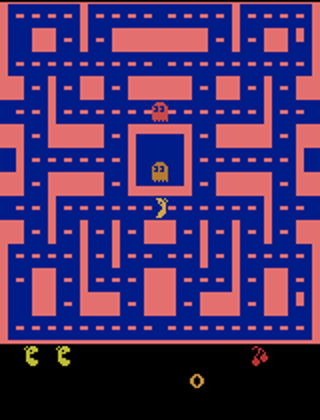

Replay pixel budget: 2692 MiB, plus model and batch memory.


In [13]:
probe_env = make_env()
try:
    probe_obs, _ = probe_env.reset(seed=SEED)
    assert probe_obs.shape == (4, 84, 84) and probe_obs.dtype == np.uint8
    assert all(np.array_equal(probe_obs[0], frame) for frame in probe_obs)
    N_ACTIONS = int(probe_env.action_space.n)
    DEVICE = select_device(N_ACTIONS)
    print("Available moves:", probe_env.unwrapped.get_action_meanings())
    display(PILImage.fromarray(probe_env.render()).resize((320, 420)))
finally:
    probe_env.close()
print(f"Replay pixel budget: {REPLAY_CAPACITY * 8 * 84 * 84 / 2**20:.0f} MiB, plus model and batch memory.")


## 4. gameplay, scores, and saved results

Evaluation uses a separate game environment and the same five seeds before and after training.
It uses 5% random moves in both cases. Evaluation never changes the network or training memory.
The baseline is an **untrained network**, not a random-action agent.

GIFs show the first 20 seconds at most, compressed to about five seconds at 4× speed; the reported score covers the entire evaluated game, up to the fixed time limit.

### 4a. score complete games and record a short sample

All evaluation games run at full computing speed, with no waiting for playback. We record a short excerpt, but add rewards for the **entire game**. For the final preview we keep the excerpt from the game with the highest full-game score.

In [14]:
def evaluate(model, seeds, gif_path=None, record_best=False):
    env = make_env()
    scores, lengths, capped = [], [], []
    best_score, chosen_frames = -float("inf"), []
    was_training = model.training
    model.eval()
    try:
        for index, seed in enumerate(seeds):
            rng = random.Random(seed + 10000)
            obs, _ = env.reset(seed=seed)
            total, frames = 0.0, []
            capture = gif_path is not None and (record_best or index == 0)
            for step in range(MAX_STEPS):
                if capture and step < PREVIEW_DECISIONS and step % PREVIEW_STRIDE == 0:
                    frames.append(PILImage.fromarray(env.render()).copy())
                action = choose_action(model, obs, EVAL_EXPLORATION, rng, N_ACTIONS)
                obs, reward, ended, truncated, _ = env.step(action)
                total += reward
                if ended or truncated:
                    break
            scores.append(float(total))
            lengths.append(step + 1)
            capped.append(bool(truncated))
            if capture and (not record_best or total > best_score):
                chosen_frames, best_score = frames, total
    finally:
        env.close()
        model.train(was_training)
    if gif_path is not None and chosen_frames:
        chosen_frames[0].save(gif_path, save_all=True, append_images=chosen_frames[1:],
                              duration=PREVIEW_FRAME_MS, loop=PREVIEW_PLAYS - 1)
    return {"seeds": list(seeds), "scores": scores, "mean": float(np.mean(scores)),
            "steps": lengths, "time_limited": capped}

### 4b. show the sample

Always keep a playable GIF in the notebook. Both the inline GIF and the popup play exactly twice. When a local desktop and Tk are available, the separate floating player does not block the next learning update.

In [15]:
def show_sample(gif_path, label):
    """Display a recorded excerpt inline and, locally, above the notebook."""
    print(f"{label} | {PREVIEW_SPEED}× playback | {PREVIEW_PLAYS} plays | first {PREVIEW_SECONDS}s of game time")
    display(Image(filename=str(gif_path)))
    if not SHOW_POPUPS:
        return
    try:
        from pacman_player import show_popup
        opened = show_popup(gif_path, f"{label} · {PREVIEW_SPEED}× speed")
        if not opened:
            print("Popup unavailable in this kernel; use the fast inline preview.")
    except (ImportError, OSError) as error:
        print(f"Using the inline preview. Local popup helper unavailable: {error}")

### 4c. save portable playback weights

Intermediate checkpoints store weights and action count. The final run also saves
optimizer, target network, replay, and random-generator state in a separate local
learner snapshot. Emulator states are not saved, so this is not exact game resumption.


In [16]:
def save_checkpoint(model, path, episode, steps):
    payload = {"model": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
               "n_actions": N_ACTIONS, "episode": episode, "steps": steps,
               "exploration": EXPLORATION, "learning_rate": LEARNING_RATE,
               "warm_start_run": WARM_START_RUN,
               "inherited_episodes": WARM_START_EPISODES,
               "inherited_decisions": WARM_START_DECISIONS,
               "inherited_updates": WARM_START_UPDATES}
    temporary = path.with_suffix(".tmp")
    torch.save(payload, temporary)
    temporary.replace(path)


### 4d. save one row per game

The CSV keeps each completed game’s raw score, decisions, exploration, loss, and elapsed time. A game with no learning updates has no meaningful loss yet.

In [17]:
def save_metrics(rows, path):
    fields = ["episode", "training_episode_id", "seed", "score", "steps", "total_steps",
              "exploration", "mean_loss", "elapsed_seconds", "terminated", "truncated",
              "lives_lost", "shaped_return"]
    temporary = path.with_suffix(".tmp")
    with temporary.open("w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fields)
        writer.writeheader()
        writer.writerows(rows)
    temporary.replace(path)


### 4e. draw the learning dashboard

The three panels show scores, prediction error, and exploration. Look at game scores as well as loss: reducing prediction error does not guarantee better play.

In [18]:
def plot_training(rows, path):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    if rows:
        episodes = [r["episode"] for r in rows]
        scores = [r["score"] for r in rows]
        smooth = [np.mean(scores[max(0, i - 24):i + 1]) for i in range(len(scores))]
        axes[0].plot(episodes, scores, alpha=0.35, label="Each training game")
        axes[0].plot(episodes, smooth, label="Up to 25-game average")
        if "selected_episode" in globals():
            axes[0].axvline(selected_episode, color="green", linestyle="--", linewidth=1, label="Validation-selected checkpoint")
        axes[0].legend(fontsize=7)
        axes[1].plot(episodes, [r["mean_loss"] for r in rows])
        axes[2].plot(episodes, [r["exploration"] for r in rows])
    for ax, title in zip(axes, ["Raw training score", "Mean update loss", "Training exploration"]):
        ax.set(title=title, xlabel="Completed episode")
        ax.grid(alpha=0.2)
    axes[2].set_ylim(0, 1.05)
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.close(fig)

## 5. train your agent

The setup cell below starts a **fresh experiment** each time, using your three choices.
It saves the untrained baseline, trains, and prints a line after each episode plus a progress update every 500 decisions.
Every 25 episodes it opens a fast gameplay sample and saves a checkpoint and plot.

To stop early, use the notebook's **Interrupt / Stop** button once. The current model and completed-episode results are saved.
Then run the remaining cells to evaluate and download them. A run ending before warm-up finishes has no learning updates yet.
Each run has its own folder so earlier experiments stay available.

### 5a. initialize the genuine untrained baseline

Create fresh networks with the same seed as before. Measure this untrained network
first, then load the documented starting weights. The learner's optimizer and
replay begin fresh; inherited training is reported separately.


In [19]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
train_rng = random.Random(SEED)
RUN_DIR = Path("pacman_runs") / datetime.now().strftime("%Y%m%d_%H%M%S_%f")
RUN_DIR.mkdir(parents=True, exist_ok=False)
(RUN_DIR / "demos").mkdir()
model = DQN(N_ACTIONS).to(DEVICE)
target = DQN(N_ACTIONS).to(DEVICE)
target.load_state_dict(model.state_dict())
target.eval()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
replay = PrioritizedNStepReplay(REPLAY_CAPACITY, n_step=N_STEP, gamma=GAMMA,
                                alpha=PRIORITY_ALPHA, seed=SEED + 1, n_envs=NUM_TRAIN_ENVS)
history, demo_history = [], []
total_steps, completed_episodes, updates, episodes_started = 0, 0, 0, 0
loss_sum, training_lives_lost = 0.0, 0
training_states = []
_training_started = False

selection_history = []
best_validation_metric = -float("inf")
selected_episode = 0
selected_updates = 0


### 5b. record the settings and test saving

Save the hardware and settings alongside the initial weights. Reload those weights immediately to catch any checkpoint problem before training.

In [20]:
config = {"algorithm": "3-step prioritized Double DQN", "training_time_limit_seconds": TRAINING_TIME_LIMIT_SECONDS,
          "exploration": EXPLORATION, "episodes_requested": EPISODES, "learning_rate": LEARNING_RATE,
          "seed": SEED, "device": str(DEVICE), "python": platform.python_version(),
          "platform": platform.platform(), "packages": VERSIONS,
          "environment": "ALE/MsPacman-v5", "frame_skip": FRAME_SKIP,
          "sticky_action_probability": 0.25, "noop_max": 30, "grayscale_size": 84,
          "stack_size": 4, "terminal_on_life_loss": False, "max_decisions_per_game": MAX_STEPS,
          "replay_capacity": REPLAY_CAPACITY, "warmup_decisions": WARMUP_STEPS,
          "batch_size": BATCH_SIZE, "train_every_decisions": TRAIN_EVERY,
          "target_sync_decisions": TARGET_EVERY, "gamma": GAMMA,
          "training_reward_clipping": None, "training_reward_scale": TRAINING_REWARD_SCALE,
          "training_reward_transform": "raw_points * 0.01 (no clipping)",
          "training_death_penalty": -LIFE_LOSS_PENALTY, "eval_exploration": EVAL_EXPLORATION,
          "eval_seeds": EVAL_SEEDS, "preview_seconds": PREVIEW_SECONDS,
          "preview_speed": PREVIEW_SPEED, "preview_plays": PREVIEW_PLAYS,
          "preview_stride": PREVIEW_STRIDE,
          "preview_frame_ms": PREVIEW_FRAME_MS}
config.update({"learning_starts_decisions": LEARNING_STARTS, "n_step": N_STEP,
               "num_training_envs": NUM_TRAIN_ENVS, "priority_alpha": PRIORITY_ALPHA,
               "priority_beta_start": PRIORITY_BETA_START,
               "priority_beta_end": 1.0, "priority_beta_decisions": PRIORITY_BETA_DECISIONS,
               "training_life_loss_terminal": False,
               "training_reward_transform": "raw_points * 0.01 - 0.5 * lives_lost (no clipping)",
               "training_seed_offset": WARM_START_EPISODES,
               "warm_start": {"run_id": WARM_START_RUN, "url": WARM_START_URL,
                              "sha256": WARM_START_SHA256, "completed_episodes": WARM_START_EPISODES,
                              "decisions": WARM_START_DECISIONS, "recorded_updates": WARM_START_UPDATES,
                              "optimizer_and_replay_reset": True},
               "training_cap_clock": "time.time wall clock", "show_popups": SHOW_POPUPS,
               "additional_validation_seeds": list(range(30001, 30021)),
               "validation_seeds": VALIDATION_SEEDS, "validation_every_episodes": VALIDATION_EVERY,
               "selection_metric": "mean(raw scores) - 0.5 * population_std(raw scores)",
               "selection_tie_break": "retain earlier checkpoint",
               "success_criterion": "class mean >= 3000 and at least 18/20 additional games >= 3000"})
(RUN_DIR / "config.json").write_text(json.dumps(config, indent=2))
save_checkpoint(model, RUN_DIR / "untrained.pt", 0, 0)
# Check saving and loading before starting the long run.
roundtrip = torch.load(RUN_DIR / "untrained.pt", map_location="cpu", weights_only=True)
assert all(torch.equal(v.cpu(), roundtrip["model"][k]) for k, v in model.state_dict().items())
del roundtrip


### 5c. measure the untrained baseline, then verify the warm start

The class comparison retains a genuine untrained network. A second, explicitly
labeled evaluation checks the inherited model before additional learning. Both
use exactly the same five seeds, 5% exploration, and time limit. Starting weights
are available in a public release and checked against their recorded SHA-256.


Evaluating the untrained network on five games.


Untrained baseline: [350.0, 500.0, 320.0, 800.0, 490.0] | mean: 492.0
Untrained baseline | 4× playback | 2 plays | first 20s of game time


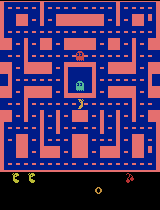

Inherited trained starting point: [1430.0, 1050.0, 1860.0, 1930.0, 980.0] | mean: 1450.0
Additional training starts from these weights with a fresh optimizer and replay.


In [21]:
print("Evaluating the untrained network on five games.", flush=True)
baseline = evaluate(model, EVAL_SEEDS, RUN_DIR / "demos" / "episode_0000.gif")
(RUN_DIR / "baseline.json").write_text(json.dumps(baseline, indent=2))
print("Untrained baseline:", baseline["scores"], "| mean:", baseline["mean"])
show_sample(RUN_DIR / "demos" / "episode_0000.gif", "Untrained baseline")

import hashlib
import urllib.request
source_path = RUN_DIR / "warm_start_source.pt"
local_source = Path("pacman_runs") / WARM_START_RUN / "trained.pt"
if local_source.exists():
    shutil.copy2(local_source, source_path)
else:
    urllib.request.urlretrieve(WARM_START_URL, source_path)
assert hashlib.sha256(source_path.read_bytes()).hexdigest() == WARM_START_SHA256
source = torch.load(source_path, map_location="cpu", weights_only=True)
assert source["n_actions"] == N_ACTIONS
model.load_state_dict(source["model"])
target.load_state_dict(model.state_dict())
assert all(torch.isfinite(x).all() for x in model.state_dict().values())
save_checkpoint(model, RUN_DIR / "initialized.pt", 0, 0)
warm_start_evaluation = evaluate(model, EVAL_SEEDS)
(RUN_DIR / "warm_start_evaluation.json").write_text(json.dumps(warm_start_evaluation, indent=2))
print("Inherited trained starting point:", warm_start_evaluation["scores"],
      "| mean:", warm_start_evaluation["mean"])
print("Additional training starts from these weights with a fresh optimizer and replay.")


### 5d. collect from four games and train one shared network

Action predictions are batched for four independent environments. The same learner
updates once per four total decisions. Each game still ends only at game over or
the original 3,000-decision time limit. New training seeds continue beyond the
source experiment. Life loss is detected only for the disclosed training reward;
the network still observes only the four game images.


In [22]:
class TrainingBudgetReached(Exception):
    pass


def check_training_budget():
    if time.time() - started >= TRAINING_TIME_LIMIT_SECONDS:
        raise TrainingBudgetReached


@torch.no_grad()
def choose_training_actions(active):
    actions, greedy_slots = {}, []
    for offset, slot in enumerate(active):
        epsilon = 1.0 if total_steps + offset < WARMUP_STEPS else EXPLORATION
        if train_rng.random() < epsilon:
            actions[slot] = train_rng.randrange(N_ACTIONS)
        else:
            greedy_slots.append(slot)
    if greedy_slots:
        screens = np.stack([training_states[slot]["obs"] for slot in greedy_slots])
        predictions = model(torch.as_tensor(screens, device=DEVICE)).argmax(dim=1).cpu().numpy()
        actions.update(zip(greedy_slots, map(int, predictions)))
    return actions


def start_training_game(env, slot):
    global episodes_started
    if episodes_started >= EPISODES:
        return None
    episodes_started += 1
    training_seed = SEED + WARM_START_EPISODES + episodes_started
    obs, info = env.reset(seed=training_seed)
    return {"obs": obs, "lives": int(info.get("lives", env.unwrapped.ale.lives())),
            "score": 0.0, "steps": 0, "lives_lost": 0, "shaped_return": 0.0,
            "episode_id": episodes_started, "seed": training_seed,
            "start_updates": updates, "start_loss_sum": loss_sum}


def train_batched_games(envs):
    global total_steps, completed_episodes, updates, loss_sum, training_lives_lost
    while any(state is not None for state in training_states):
        check_training_budget()
        active = [i for i, state in enumerate(training_states) if state is not None]
        actions = choose_training_actions(active)
        for slot in active:
            check_training_budget()
            state, env = training_states[slot], envs[slot]
            obs = state["obs"]
            next_obs, reward, ended, truncated, info = env.step(actions[slot])
            lives = int(info.get("lives", env.unwrapped.ale.lives()))
            lost = max(0, state["lives"] - lives)
            training_reward = float(reward) * TRAINING_REWARD_SCALE - LIFE_LOSS_PENALTY * lost
            replay.add(slot, obs, actions[slot], training_reward, next_obs, ended, truncated)
            state["obs"], state["lives"] = next_obs, lives
            state["score"] += float(reward)
            state["shaped_return"] += training_reward
            state["steps"] += 1
            state["lives_lost"] += lost
            training_lives_lost += lost
            total_steps += 1
            if total_steps >= LEARNING_STARTS and len(replay) >= BATCH_SIZE and total_steps % TRAIN_EVERY == 0:
                beta = PRIORITY_BETA_START + (1.0 - PRIORITY_BETA_START) * min(1.0, total_steps / PRIORITY_BETA_DECISIONS)
                batch = replay.sample(BATCH_SIZE, beta=beta)
                loss, errors = learn(model, target, optimizer, batch)
                updates += 1
                loss_sum += loss
                replay.update_priorities(batch["indices"], errors)
            if total_steps % TARGET_EVERY == 0:
                target.load_state_dict(model.state_dict())
            if total_steps % 5000 == 0:
                print(f"Progress | {completed_episodes}/{EPISODES} complete games | "
                      f"{total_steps:,} decisions | {updates:,} updates | "
                      f"{(time.time() - started) / 60:.1f} min", flush=True)
            if ended or truncated:
                completed_episodes += 1
                episode_updates = updates - state["start_updates"]
                row = {"episode": completed_episodes, "training_episode_id": state["episode_id"],
                       "seed": state["seed"], "score": state["score"], "steps": state["steps"],
                       "total_steps": total_steps,
                       "exploration": 1.0 if total_steps < WARMUP_STEPS else EXPLORATION,
                       "mean_loss": (loss_sum - state["start_loss_sum"]) / episode_updates if episode_updates else float("nan"),
                       "elapsed_seconds": time.time() - started,
                       "terminated": bool(ended), "truncated": bool(truncated),
                       "lives_lost": state["lives_lost"], "shaped_return": state["shaped_return"]}
                history.append(row)
                training_states[slot] = None
                save_metrics(history, RUN_DIR / "training.csv")
                recent = np.mean([game["score"] for game in history[-25:]])
                print(f"Episode {completed_episodes}/{EPISODES} | score {row['score']:.0f} | "
                      f"recent mean {recent:.1f} | exploration {EXPLORATION:.0%}", flush=True)
                if completed_episodes % DEMO_EVERY == 0:
                    save_progress_sample(completed_episodes)
                if completed_episodes % VALIDATION_EVERY == 0:
                    assess_candidate(completed_episodes, "periodic")
                check_training_budget()
                training_states[slot] = start_training_game(env, slot)


### 5e. preserve every intermediate sample

Every 25 completed games, use a separate evaluation environment to save a short
GIF and a playback checkpoint. These demos do not train the model and are not used
to select the final checkpoint. They remain single-seed illustrations.


In [23]:
def save_progress_sample(episode):
    gif_path = RUN_DIR / "demos" / f"episode_{episode:04d}.gif"
    demo = evaluate(model, EVAL_SEEDS[:1], gif_path)
    demo_history.append({"episode": episode, **demo})
    (RUN_DIR / "demo_scores.json").write_text(json.dumps(demo_history, indent=2))
    print("Separate demonstration score:", demo["scores"][0])
    save_checkpoint(model, RUN_DIR / f"episode_{episode:04d}.pt", episode, total_steps)
    plot_training(history, RUN_DIR / "training_dashboard.png")
    show_sample(gif_path, f"After {episode} training games")

def assess_candidate(episode, reason):
    global best_validation_metric, selected_episode, selected_updates
    print(f"Validation candidate after {episode} additional games ({reason})...", flush=True)
    result = evaluate(model, VALIDATION_SEEDS)
    spread = float(np.std(result["scores"], ddof=0))
    metric = float(result["mean"] - 0.5 * spread)
    selected = metric > best_validation_metric
    if selected:
        best_validation_metric, selected_episode, selected_updates = metric, episode, updates
        save_checkpoint(model, RUN_DIR / "validation_best.pt", episode, total_steps)
    row = {"additional_episodes": episode, "decisions": total_steps, "updates": updates,
           "reason": reason, **result, "population_std": spread, "selection_metric": metric,
           "selected_when_evaluated": selected}
    selection_history.append(row)
    record = {"criterion": "mean(raw scores) - 0.5 * population_std(raw scores)",
              "seeds": VALIDATION_SEEDS, "eval_exploration": EVAL_EXPLORATION,
              "max_decisions_per_game": MAX_STEPS, "candidate_evaluations": selection_history,
              "selected_additional_episodes": selected_episode, "selected_updates": selected_updates,
              "selected_metric": best_validation_metric}
    (RUN_DIR / "model_selection.json").write_text(json.dumps(record, indent=2))
    print(f"Validation scores {result['scores']} | mean {result['mean']:.1f} | "
          f"selection metric {metric:.1f} | new selected model: {selected}", flush=True)


### 5f. save weights, evidence, and learner state

The final summary counts completed games and decisions from any interrupted games.
A separate local snapshot preserves replay, optimizer, target, and random-generator
state for future work. It does not preserve live emulator states, so a later run
must reset games and handle pending replay queues; it is not exact resumption.


In [24]:
def save_training_result(status):
    stopped_wall = time.time() - started
    stopped_active = time.monotonic() - active_started
    save_checkpoint(model, RUN_DIR / "last_trained.pt", completed_episodes, total_steps)
    assess_candidate(completed_episodes, "final candidate")
    shutil.copy2(RUN_DIR / "validation_best.pt", RUN_DIR / "trained.pt")
    save_metrics(history, RUN_DIR / "training.csv")
    plot_training(history, RUN_DIR / "training_dashboard.png")
    partial = [{"slot": slot, "training_episode_id": state["episode_id"],
                "seed": state["seed"], "decisions": state["steps"], "score": state["score"],
                "lives_lost": state["lives_lost"]}
               for slot, state in enumerate(training_states) if state is not None]
    summary = {"status": status, "completed_episodes": completed_episodes,
               "episodes_started": episodes_started, "total_decisions": total_steps,
               "learning_updates": updates, "training_time_limit_seconds": TRAINING_TIME_LIMIT_SECONDS,
               "elapsed_seconds_including_periodic_demos": stopped_wall,
               "active_monotonic_elapsed_seconds": stopped_active,
               "partial_games": partial, "training_lives_lost": training_lives_lost,
               "replay_size": len(replay),
               "selected_additional_episodes": selected_episode,
               "selected_recorded_updates": selected_updates,
               "selected_validation_metric": best_validation_metric, "inherited_completed_episodes": WARM_START_EPISODES,
               "inherited_decisions": WARM_START_DECISIONS, "inherited_recorded_updates": WARM_START_UPDATES,
               "cumulative_completed_episodes": WARM_START_EPISODES + completed_episodes,
               "cumulative_decisions": WARM_START_DECISIONS + total_steps,
               "cumulative_recorded_updates": WARM_START_UPDATES + updates}
    (RUN_DIR / "training_summary.json").write_text(json.dumps(summary, indent=2))
    print("Saving local learner snapshot (optimizer, target, replay and random states)...", flush=True)
    learner_state = {"model": {k: v.detach().cpu() for k,v in model.state_dict().items()},
                     "target": {k: v.detach().cpu() for k,v in target.state_dict().items()},
                     "optimizer": optimizer.state_dict(), "replay": replay.state_dict(copy_arrays=False),
                     "train_rng": train_rng.getstate(), "python_rng": random.getstate(),
                     "numpy_rng": np.random.get_state(), "torch_rng": torch.get_rng_state(),
                     "summary": summary, "emulator_states_saved": False}
    if DEVICE.type == "mps":
        learner_state["mps_rng"] = torch.mps.get_rng_state()
    temporary = RUN_DIR / "learner_state.tmp"
    torch.save(learner_state, temporary, pickle_protocol=5)
    temporary.replace(RUN_DIR / "learner_state.pt")
    print("Saved learner snapshot; final evaluation follows.", flush=True)


### 5g. run additional training and select on separate validation games

The cap uses wall time. Four simultaneous games share total decision/update counters.
Every 250 completed games, evaluate ten validation seeds (20001–20010), disjoint
from the five classroom seeds, training resets, and the final 20 additional games.
Select the checkpoint with the largest mean score minus half its score standard
deviation; retain the earlier checkpoint on ties. The inherited model is an eligible
starting candidate, protecting against a training regression. Assess the last model
once more after training and preserve it separately even if another candidate wins.
The selected model is then evaluated once on the unchanged classroom five games.


Validation candidate after 0 additional games (inherited starting model)...


Validation scores [1080.0, 1310.0, 1010.0, 990.0, 770.0, 900.0, 1010.0, 2390.0, 780.0, 1750.0] | mean 1199.0 | selection metric 958.5 | new selected model: True


Episode 1/2500 | score 350 | recent mean 350.0 | exploration 10%


Episode 2/2500 | score 270 | recent mean 310.0 | exploration 10%


Episode 3/2500 | score 1380 | recent mean 666.7 | exploration 10%


...

Episode 23/2500 | score 2080 | recent mean 1036.1 | exploration 10%


Episode 24/2500 | score 1250 | recent mean 1045.0 | exploration 10%


Episode 25/2500 | score 1620 | recent mean 1068.0 | exploration 10%


Separate demonstration score: 730.0


After 25 training games | 4× playback | 2 plays | first 20s of game time


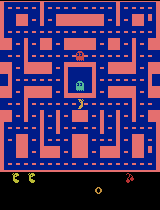

Episode 26/2500 | score 1370 | recent mean 1108.8 | exploration 10%


Episode 27/2500 | score 1320 | recent mean 1150.8 | exploration 10%


Episode 28/2500 | score 660 | recent mean 1122.0 | exploration 10%


Progress | 28/2500 complete games | 20,000 decisions | 2,501 updates | 1.5 min


Episode 29/2500 | score 660 | recent mean 1124.4 | exploration 10%


...

Episode 49/2500 | score 1050 | recent mean 1156.4 | exploration 10%


Progress | 49/2500 complete games | 35,000 decisions | 6,251 updates | 2.8 min


Episode 50/2500 | score 1950 | recent mean 1169.6 | exploration 10%


Separate demonstration score: 920.0


After 50 training games | 4× playback | 2 plays | first 20s of game time


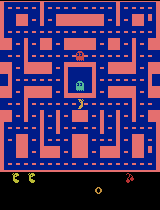

Episode 51/2500 | score 960 | recent mean 1153.2 | exploration 10%


Episode 52/2500 | score 2700 | recent mean 1208.4 | exploration 10%


Episode 53/2500 | score 1370 | recent mean 1236.8 | exploration 10%


Episode 54/2500 | score 1250 | recent mean 1260.4 | exploration 10%


Episode 55/2500 | score 1070 | recent mean 1252.8 | exploration 10%


...

Episode 73/2500 | score 1030 | recent mean 1292.0 | exploration 10%


Episode 74/2500 | score 870 | recent mean 1284.8 | exploration 10%


Episode 75/2500 | score 570 | recent mean 1229.6 | exploration 10%


Separate demonstration score: 680.0


After 75 training games | 4× playback | 2 plays | first 20s of game time


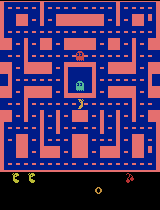

Episode 76/2500 | score 1070 | recent mean 1234.0 | exploration 10%


Progress | 76/2500 complete games | 55,000 decisions | 11,251 updates | 4.7 min


Episode 77/2500 | score 1000 | recent mean 1166.0 | exploration 10%


Episode 78/2500 | score 770 | recent mean 1142.0 | exploration 10%


Episode 79/2500 | score 1340 | recent mean 1145.6 | exploration 10%


...

Episode 98/2500 | score 2520 | recent mean 1213.2 | exploration 10%


Episode 99/2500 | score 1210 | recent mean 1226.8 | exploration 10%


Episode 100/2500 | score 1140 | recent mean 1249.6 | exploration 10%


Separate demonstration score: 1100.0


After 100 training games | 4× playback | 2 plays | first 20s of game time


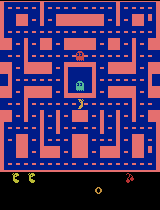

Episode 101/2500 | score 1550 | recent mean 1268.8 | exploration 10%


Episode 102/2500 | score 1190 | recent mean 1276.4 | exploration 10%


Episode 103/2500 | score 2060 | recent mean 1328.0 | exploration 10%


Progress | 103/2500 complete games | 75,000 decisions | 16,251 updates | 6.6 min


Episode 104/2500 | score 2170 | recent mean 1361.2 | exploration 10%


...

Episode 123/2500 | score 4010 | recent mean 1383.2 | exploration 10%


Episode 124/2500 | score 1600 | recent mean 1398.8 | exploration 10%


Episode 125/2500 | score 400 | recent mean 1369.2 | exploration 10%


Separate demonstration score: 800.0


After 125 training games | 4× playback | 2 plays | first 20s of game time


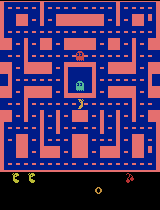

Episode 126/2500 | score 1490 | recent mean 1366.8 | exploration 10%


Episode 127/2500 | score 1170 | recent mean 1366.0 | exploration 10%


Episode 128/2500 | score 650 | recent mean 1309.6 | exploration 10%


Episode 129/2500 | score 650 | recent mean 1248.8 | exploration 10%


Progress | 129/2500 complete games | 95,000 decisions | 21,251 updates | 8.9 min


...

Episode 148/2500 | score 850 | recent mean 1070.8 | exploration 10%


Episode 149/2500 | score 3820 | recent mean 1159.6 | exploration 10%


Progress | 149/2500 complete games | 110,000 decisions | 25,001 updates | 10.2 min


Episode 150/2500 | score 1340 | recent mean 1197.2 | exploration 10%


Separate demonstration score: 1240.0
After 150 training games | 4× playback | 2 plays | first 20s of game time


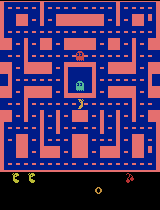

Episode 151/2500 | score 540 | recent mean 1159.2 | exploration 10%


Episode 152/2500 | score 810 | recent mean 1144.8 | exploration 10%


Episode 153/2500 | score 1570 | recent mean 1181.6 | exploration 10%


Episode 154/2500 | score 990 | recent mean 1195.2 | exploration 10%


Episode 155/2500 | score 1520 | recent mean 1214.8 | exploration 10%


...

Episode 172/2500 | score 1700 | recent mean 1406.4 | exploration 10%


Episode 173/2500 | score 1330 | recent mean 1425.6 | exploration 10%


Episode 174/2500 | score 1070 | recent mean 1315.6 | exploration 10%


Episode 175/2500 | score 2020 | recent mean 1342.8 | exploration 10%


Separate demonstration score: 1370.0
After 175 training games | 4× playback | 2 plays | first 20s of game time


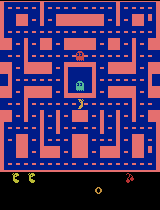

Progress | 175/2500 complete games | 130,000 decisions | 30,001 updates | 12.0 min


Episode 176/2500 | score 1810 | recent mean 1393.6 | exploration 10%


Episode 177/2500 | score 1060 | recent mean 1403.6 | exploration 10%


Episode 178/2500 | score 480 | recent mean 1360.0 | exploration 10%


Episode 179/2500 | score 760 | recent mean 1350.8 | exploration 10%


...

Episode 197/2500 | score 710 | recent mean 1303.2 | exploration 10%


Episode 198/2500 | score 2120 | recent mean 1334.8 | exploration 10%


Episode 199/2500 | score 540 | recent mean 1313.6 | exploration 10%


Episode 200/2500 | score 1020 | recent mean 1273.6 | exploration 10%


Separate demonstration score: 1270.0
After 200 training games | 4× playback | 2 plays | first 20s of game time


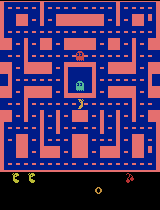

Episode 201/2500 | score 910 | recent mean 1237.6 | exploration 10%


Progress | 201/2500 complete games | 150,000 decisions | 35,001 updates | 13.8 min


Episode 202/2500 | score 880 | recent mean 1230.4 | exploration 10%


Episode 203/2500 | score 1610 | recent mean 1275.6 | exploration 10%


Episode 204/2500 | score 1310 | recent mean 1297.6 | exploration 10%


...

Episode 222/2500 | score 920 | recent mean 1132.0 | exploration 10%


Episode 223/2500 | score 550 | recent mean 1069.2 | exploration 10%


Episode 224/2500 | score 880 | recent mean 1082.8 | exploration 10%


Episode 225/2500 | score 980 | recent mean 1081.2 | exploration 10%


Separate demonstration score: 1110.0
After 225 training games | 4× playback | 2 plays | first 20s of game time


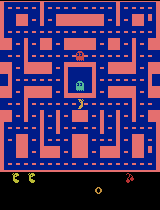

Episode 226/2500 | score 1310 | recent mean 1097.2 | exploration 10%


Progress | 226/2500 complete games | 170,000 decisions | 40,001 updates | 15.7 min


Episode 227/2500 | score 950 | recent mean 1100.0 | exploration 10%


Episode 228/2500 | score 1350 | recent mean 1089.6 | exploration 10%


Episode 229/2500 | score 1190 | recent mean 1084.8 | exploration 10%


...

Progress | 247/2500 complete games | 185,000 decisions | 43,751 updates | 17.2 min


Episode 248/2500 | score 700 | recent mean 1069.2 | exploration 10%


Episode 249/2500 | score 800 | recent mean 1066.0 | exploration 10%


Episode 250/2500 | score 1030 | recent mean 1068.0 | exploration 10%


Separate demonstration score: 430.0
After 250 training games | 4× playback | 2 plays | first 20s of game time


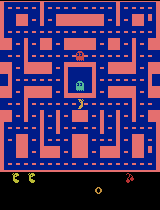

Validation candidate after 250 additional games (periodic)...


Validation scores [660.0, 640.0, 1580.0, 990.0, 1230.0, 950.0, 2280.0, 1350.0, 1610.0, 650.0] | mean 1194.0 | selection metric 943.2 | new selected model: False


Episode 251/2500 | score 1710 | recent mean 1084.0 | exploration 10%


Episode 252/2500 | score 1930 | recent mean 1123.2 | exploration 10%


Progress | 252/2500 complete games | 190,000 decisions | 45,001 updates | 17.9 min


...

Episode 272/2500 | score 1230 | recent mean 1213.2 | exploration 10%


Episode 273/2500 | score 1000 | recent mean 1225.2 | exploration 10%


Episode 274/2500 | score 2350 | recent mean 1287.2 | exploration 10%


Episode 275/2500 | score 500 | recent mean 1266.0 | exploration 10%


Separate demonstration score: 1130.0
After 275 training games | 4× playback | 2 plays | first 20s of game time


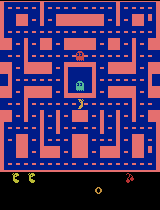

Episode 276/2500 | score 550 | recent mean 1219.6 | exploration 10%


Episode 277/2500 | score 1570 | recent mean 1205.2 | exploration 10%


Episode 278/2500 | score 900 | recent mean 1204.0 | exploration 10%


Progress | 278/2500 complete games | 210,000 decisions | 50,001 updates | 19.5 min


Episode 279/2500 | score 480 | recent mean 1178.4 | exploration 10%


...

Episode 298/2500 | score 1390 | recent mean 1295.2 | exploration 10%


Progress | 298/2500 complete games | 225,000 decisions | 53,751 updates | 20.7 min


Episode 299/2500 | score 1050 | recent mean 1243.2 | exploration 10%


Episode 300/2500 | score 810 | recent mean 1255.6 | exploration 10%


Separate demonstration score: 1340.0
After 300 training games | 4× playback | 2 plays | first 20s of game time


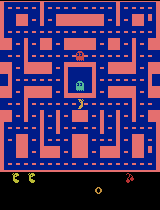

Episode 301/2500 | score 1100 | recent mean 1277.6 | exploration 10%


Episode 302/2500 | score 1400 | recent mean 1270.8 | exploration 10%


Episode 303/2500 | score 670 | recent mean 1261.6 | exploration 10%


Progress | 303/2500 complete games | 230,000 decisions | 55,001 updates | 21.1 min


Episode 304/2500 | score 1270 | recent mean 1293.2 | exploration 10%


...

Episode 323/2500 | score 460 | recent mean 1072.0 | exploration 10%


Progress | 323/2500 complete games | 245,000 decisions | 58,751 updates | 22.3 min


Episode 324/2500 | score 2390 | recent mean 1125.6 | exploration 10%


Episode 325/2500 | score 1290 | recent mean 1144.8 | exploration 10%


Separate demonstration score: 880.0
After 325 training games | 4× playback | 2 plays | first 20s of game time


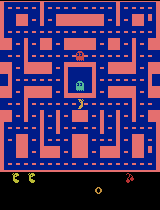

Episode 326/2500 | score 870 | recent mean 1135.6 | exploration 10%


Episode 327/2500 | score 270 | recent mean 1090.4 | exploration 10%


Episode 328/2500 | score 1190 | recent mean 1111.2 | exploration 10%


Episode 329/2500 | score 1070 | recent mean 1103.2 | exploration 10%


Episode 330/2500 | score 870 | recent mean 1082.8 | exploration 10%


...

Episode 348/2500 | score 560 | recent mean 1066.8 | exploration 10%


Episode 349/2500 | score 800 | recent mean 1003.2 | exploration 10%


Episode 350/2500 | score 1370 | recent mean 1006.4 | exploration 10%


Separate demonstration score: 1810.0


After 350 training games | 4× playback | 2 plays | first 20s of game time


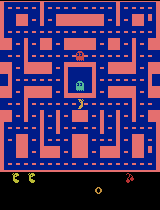

Episode 351/2500 | score 370 | recent mean 986.4 | exploration 10%


Episode 352/2500 | score 1500 | recent mean 1035.6 | exploration 10%


Episode 353/2500 | score 1610 | recent mean 1052.4 | exploration 10%


Progress | 353/2500 complete games | 265,000 decisions | 63,751 updates | 24.7 min


Episode 354/2500 | score 530 | recent mean 1030.8 | exploration 10%


...

Progress | 373/2500 complete games | 280,000 decisions | 67,501 updates | 28.2 min


Episode 374/2500 | score 1030 | recent mean 950.0 | exploration 10%


Episode 375/2500 | score 630 | recent mean 920.4 | exploration 10%


Separate demonstration score: 830.0


After 375 training games | 4× playback | 2 plays | first 20s of game time


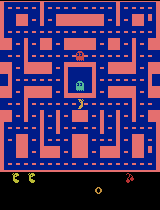

Episode 376/2500 | score 610 | recent mean 930.0 | exploration 10%


Episode 377/2500 | score 1730 | recent mean 939.2 | exploration 10%


Episode 378/2500 | score 740 | recent mean 904.4 | exploration 10%


Episode 379/2500 | score 870 | recent mean 918.0 | exploration 10%


Episode 380/2500 | score 1410 | recent mean 942.8 | exploration 10%


...

Episode 398/2500 | score 2480 | recent mean 1179.6 | exploration 10%


Episode 399/2500 | score 600 | recent mean 1162.4 | exploration 10%


Episode 400/2500 | score 2240 | recent mean 1226.8 | exploration 10%


Separate demonstration score: 2090.0


After 400 training games | 4× playback | 2 plays | first 20s of game time


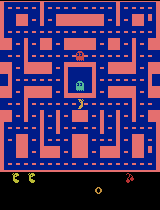

Progress | 400/2500 complete games | 300,000 decisions | 72,501 updates | 33.7 min


Episode 401/2500 | score 950 | recent mean 1240.4 | exploration 10%


Episode 402/2500 | score 510 | recent mean 1191.6 | exploration 10%


Episode 403/2500 | score 710 | recent mean 1190.4 | exploration 10%


Episode 404/2500 | score 2400 | recent mean 1251.6 | exploration 10%


...

Episode 422/2500 | score 730 | recent mean 1246.8 | exploration 10%


Episode 423/2500 | score 890 | recent mean 1183.2 | exploration 10%


Episode 424/2500 | score 870 | recent mean 1194.0 | exploration 10%


Episode 425/2500 | score 1390 | recent mean 1160.0 | exploration 10%


Separate demonstration score: 2070.0
After 425 training games | 4× playback | 2 plays | first 20s of game time


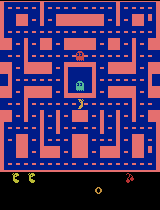

Episode 426/2500 | score 1190 | recent mean 1169.6 | exploration 10%


Progress | 426/2500 complete games | 320,000 decisions | 77,501 updates | 37.5 min


Episode 427/2500 | score 1090 | recent mean 1192.8 | exploration 10%


Episode 428/2500 | score 1450 | recent mean 1222.4 | exploration 10%


Episode 429/2500 | score 980 | recent mean 1165.6 | exploration 10%


...

Episode 448/2500 | score 1660 | recent mean 1309.2 | exploration 10%


Progress | 448/2500 complete games | 335,000 decisions | 81,251 updates | 38.9 min


Episode 449/2500 | score 480 | recent mean 1293.6 | exploration 10%


Episode 450/2500 | score 980 | recent mean 1277.2 | exploration 10%


Separate demonstration score: 1540.0
After 450 training games | 4× playback | 2 plays | first 20s of game time


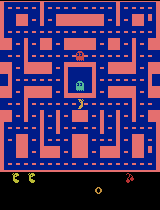

Episode 451/2500 | score 2760 | recent mean 1340.0 | exploration 10%


Episode 452/2500 | score 1600 | recent mean 1360.4 | exploration 10%


Episode 453/2500 | score 520 | recent mean 1323.2 | exploration 10%


Episode 454/2500 | score 2780 | recent mean 1395.2 | exploration 10%


Progress | 454/2500 complete games | 340,000 decisions | 82,501 updates | 39.4 min


...

Episode 473/2500 | score 1860 | recent mean 1751.6 | exploration 10%


Progress | 473/2500 complete games | 355,000 decisions | 86,251 updates | 40.8 min


Episode 474/2500 | score 2800 | recent mean 1844.4 | exploration 10%


Episode 475/2500 | score 1790 | recent mean 1876.8 | exploration 10%


Separate demonstration score: 2550.0
After 475 training games | 4× playback | 2 plays | first 20s of game time


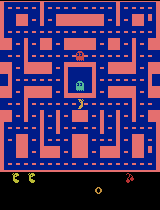

Episode 476/2500 | score 3740 | recent mean 1916.0 | exploration 10%


Episode 477/2500 | score 1090 | recent mean 1895.6 | exploration 10%


Episode 478/2500 | score 2110 | recent mean 1959.2 | exploration 10%


Progress | 478/2500 complete games | 360,000 decisions | 87,501 updates | 41.2 min


Episode 479/2500 | score 1440 | recent mean 1905.6 | exploration 10%


...

Progress | 497/2500 complete games | 375,000 decisions | 91,251 updates | 42.3 min


Episode 498/2500 | score 900 | recent mean 1806.8 | exploration 10%


Episode 499/2500 | score 1090 | recent mean 1738.4 | exploration 10%


Episode 500/2500 | score 2790 | recent mean 1778.4 | exploration 10%


Separate demonstration score: 2950.0
After 500 training games | 4× playback | 2 plays | first 20s of game time


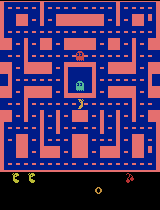

Validation candidate after 500 additional games (periodic)...


Validation scores [1370.0, 1220.0, 1690.0, 1460.0, 250.0, 930.0, 1390.0, 1180.0, 2610.0, 710.0] | mean 1281.0 | selection metric 984.7 | new selected model: True


Episode 501/2500 | score 1390 | recent mean 1684.4 | exploration 10%


Progress | 501/2500 complete games | 380,000 decisions | 92,501 updates | 42.9 min


Episode 502/2500 | score 1400 | recent mean 1696.8 | exploration 10%


...

Episode 523/2500 | score 2300 | recent mean 1769.2 | exploration 10%


Progress | 523/2500 complete games | 395,000 decisions | 96,251 updates | 43.9 min


Episode 524/2500 | score 2510 | recent mean 1826.0 | exploration 10%


Episode 525/2500 | score 670 | recent mean 1741.2 | exploration 10%


Separate demonstration score: 750.0
After 525 training games | 4× playback | 2 plays | first 20s of game time


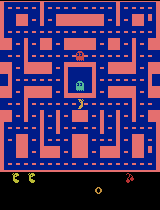

Episode 526/2500 | score 1280 | recent mean 1736.8 | exploration 10%


Episode 527/2500 | score 610 | recent mean 1705.2 | exploration 10%


Episode 528/2500 | score 1310 | recent mean 1567.2 | exploration 10%


Progress | 528/2500 complete games | 400,000 decisions | 97,501 updates | 44.3 min


Episode 529/2500 | score 780 | recent mean 1560.4 | exploration 10%


...

Episode 548/2500 | score 1150 | recent mean 1248.8 | exploration 10%


Episode 549/2500 | score 550 | recent mean 1170.4 | exploration 10%


Progress | 549/2500 complete games | 415,000 decisions | 101,251 updates | 45.3 min


Episode 550/2500 | score 2090 | recent mean 1227.2 | exploration 10%


Separate demonstration score: 1900.0
After 550 training games | 4× playback | 2 plays | first 20s of game time


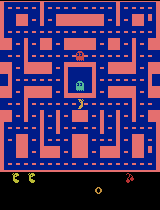

Episode 551/2500 | score 940 | recent mean 1213.6 | exploration 10%


Episode 552/2500 | score 5050 | recent mean 1391.2 | exploration 10%


Episode 553/2500 | score 860 | recent mean 1373.2 | exploration 10%


Episode 554/2500 | score 1130 | recent mean 1387.2 | exploration 10%


Episode 555/2500 | score 2440 | recent mean 1394.8 | exploration 10%


...

Episode 572/2500 | score 760 | recent mean 1372.0 | exploration 10%


Episode 573/2500 | score 1640 | recent mean 1391.6 | exploration 10%


Episode 574/2500 | score 1140 | recent mean 1415.2 | exploration 10%


Episode 575/2500 | score 1140 | recent mean 1377.2 | exploration 10%


Separate demonstration score: 1310.0
After 575 training games | 4× playback | 2 plays | first 20s of game time


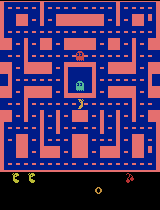

Episode 576/2500 | score 1080 | recent mean 1382.8 | exploration 10%


Progress | 576/2500 complete games | 435,000 decisions | 106,251 updates | 46.6 min


Episode 577/2500 | score 1660 | recent mean 1247.2 | exploration 10%


Episode 578/2500 | score 2670 | recent mean 1319.6 | exploration 10%


Episode 579/2500 | score 760 | recent mean 1304.8 | exploration 10%


...

Episode 598/2500 | score 1540 | recent mean 1184.0 | exploration 10%


Progress | 598/2500 complete games | 450,000 decisions | 110,001 updates | 47.6 min


Episode 599/2500 | score 460 | recent mean 1156.8 | exploration 10%


Episode 600/2500 | score 920 | recent mean 1148.0 | exploration 10%


Separate demonstration score: 1440.0
After 600 training games | 4× playback | 2 plays | first 20s of game time


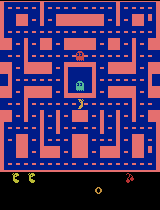

Episode 601/2500 | score 710 | recent mean 1133.2 | exploration 10%


Episode 602/2500 | score 2960 | recent mean 1185.2 | exploration 10%


Episode 603/2500 | score 790 | recent mean 1110.0 | exploration 10%


Episode 604/2500 | score 690 | recent mean 1107.2 | exploration 10%


Episode 605/2500 | score 930 | recent mean 1087.2 | exploration 10%


...

Episode 622/2500 | score 1120 | recent mean 1041.6 | exploration 10%


Episode 623/2500 | score 2160 | recent mean 1066.4 | exploration 10%


Episode 624/2500 | score 2420 | recent mean 1144.8 | exploration 10%


Episode 625/2500 | score 1910 | recent mean 1184.4 | exploration 10%


Separate demonstration score: 990.0
After 625 training games | 4× playback | 2 plays | first 20s of game time


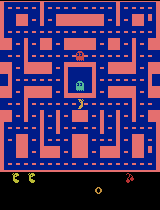

Progress | 625/2500 complete games | 470,000 decisions | 115,001 updates | 49.0 min


Episode 626/2500 | score 2250 | recent mean 1246.0 | exploration 10%


Episode 627/2500 | score 560 | recent mean 1150.0 | exploration 10%


Episode 628/2500 | score 1040 | recent mean 1160.0 | exploration 10%


Episode 629/2500 | score 1670 | recent mean 1199.2 | exploration 10%


...

Episode 647/2500 | score 1580 | recent mean 1279.2 | exploration 10%


Episode 648/2500 | score 1560 | recent mean 1255.2 | exploration 10%


Episode 649/2500 | score 1330 | recent mean 1211.6 | exploration 10%


Episode 650/2500 | score 1540 | recent mean 1196.8 | exploration 10%


Separate demonstration score: 1250.0
After 650 training games | 4× playback | 2 plays | first 20s of game time


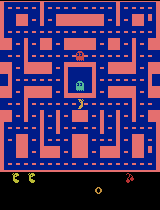

Episode 651/2500 | score 630 | recent mean 1132.0 | exploration 10%


Progress | 651/2500 complete games | 490,000 decisions | 120,001 updates | 50.3 min


Episode 652/2500 | score 750 | recent mean 1139.6 | exploration 10%


Episode 653/2500 | score 1840 | recent mean 1171.6 | exploration 10%


Episode 654/2500 | score 1060 | recent mean 1147.2 | exploration 10%


...

Episode 672/2500 | score 780 | recent mean 1410.4 | exploration 10%


Episode 673/2500 | score 1120 | recent mean 1392.8 | exploration 10%


Episode 674/2500 | score 990 | recent mean 1379.2 | exploration 10%


Episode 675/2500 | score 1760 | recent mean 1388.0 | exploration 10%


Separate demonstration score: 1190.0
After 675 training games | 4× playback | 2 plays | first 20s of game time


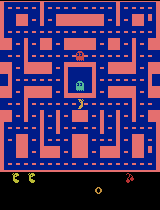

Episode 676/2500 | score 1520 | recent mean 1423.6 | exploration 10%


Progress | 676/2500 complete games | 510,000 decisions | 125,001 updates | 51.7 min


Episode 677/2500 | score 2210 | recent mean 1482.0 | exploration 10%


Episode 678/2500 | score 1640 | recent mean 1474.0 | exploration 10%


Episode 679/2500 | score 2420 | recent mean 1528.4 | exploration 10%


...

Episode 697/2500 | score 540 | recent mean 1434.0 | exploration 10%


Episode 698/2500 | score 610 | recent mean 1413.6 | exploration 10%


Episode 699/2500 | score 490 | recent mean 1393.6 | exploration 10%


Episode 700/2500 | score 1050 | recent mean 1365.2 | exploration 10%


Separate demonstration score: 1630.0
After 700 training games | 4× playback | 2 plays | first 20s of game time


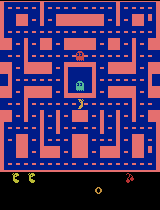

Episode 701/2500 | score 500 | recent mean 1324.4 | exploration 10%


Episode 702/2500 | score 880 | recent mean 1271.2 | exploration 10%


Episode 703/2500 | score 1430 | recent mean 1262.8 | exploration 10%


Progress | 703/2500 complete games | 530,000 decisions | 130,001 updates | 53.1 min


Episode 704/2500 | score 1120 | recent mean 1210.8 | exploration 10%


...

Episode 723/2500 | score 790 | recent mean 1420.0 | exploration 10%


Episode 724/2500 | score 1440 | recent mean 1458.0 | exploration 10%


Episode 725/2500 | score 2190 | recent mean 1503.6 | exploration 10%


Separate demonstration score: 710.0


After 725 training games | 4× playback | 2 plays | first 20s of game time


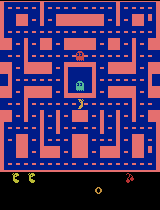

Episode 726/2500 | score 1340 | recent mean 1537.2 | exploration 10%


Episode 727/2500 | score 2180 | recent mean 1589.2 | exploration 10%


Episode 728/2500 | score 1190 | recent mean 1579.6 | exploration 10%


Progress | 728/2500 complete games | 550,000 decisions | 135,001 updates | 54.4 min


Episode 729/2500 | score 1290 | recent mean 1586.4 | exploration 10%


...

Episode 748/2500 | score 1530 | recent mean 1485.6 | exploration 10%


Progress | 748/2500 complete games | 565,000 decisions | 138,751 updates | 55.4 min


Episode 749/2500 | score 770 | recent mean 1458.8 | exploration 10%


Episode 750/2500 | score 740 | recent mean 1400.8 | exploration 10%


Separate demonstration score: 1220.0
After 750 training games | 4× playback | 2 plays | first 20s of game time


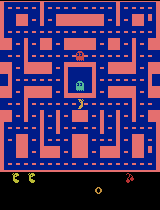

Validation candidate after 750 additional games (periodic)...


Validation scores [4030.0, 960.0, 1200.0, 2330.0, 1380.0, 1450.0, 1560.0, 780.0, 2280.0, 1200.0] | mean 1717.0 | selection metric 1263.2 | new selected model: True


Episode 751/2500 | score 1100 | recent mean 1391.2 | exploration 10%


Episode 752/2500 | score 2390 | recent mean 1399.6 | exploration 10%


Episode 753/2500 | score 860 | recent mean 1386.4 | exploration 10%


...

Episode 772/2500 | score 1730 | recent mean 1544.0 | exploration 10%


Episode 773/2500 | score 1240 | recent mean 1532.4 | exploration 10%


Episode 774/2500 | score 1150 | recent mean 1547.6 | exploration 10%


Episode 775/2500 | score 1230 | recent mean 1567.2 | exploration 10%


Separate demonstration score: 1410.0
After 775 training games | 4× playback | 2 plays | first 20s of game time


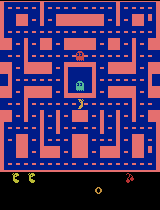

Episode 776/2500 | score 1110 | recent mean 1567.6 | exploration 10%


Episode 777/2500 | score 2320 | recent mean 1564.8 | exploration 10%


Progress | 777/2500 complete games | 590,000 decisions | 145,001 updates | 57.4 min


Episode 778/2500 | score 1810 | recent mean 1602.8 | exploration 10%


Episode 779/2500 | score 1690 | recent mean 1635.6 | exploration 10%


...

Progress | 797/2500 complete games | 605,000 decisions | 148,751 updates | 58.4 min


Episode 798/2500 | score 1720 | recent mean 1524.0 | exploration 10%


Episode 799/2500 | score 1460 | recent mean 1536.4 | exploration 10%


Episode 800/2500 | score 970 | recent mean 1526.0 | exploration 10%


Separate demonstration score: 2220.0
After 800 training games | 4× playback | 2 plays | first 20s of game time


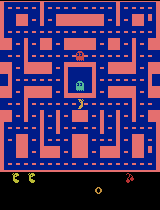

Episode 801/2500 | score 1720 | recent mean 1550.4 | exploration 10%


Episode 802/2500 | score 1980 | recent mean 1536.8 | exploration 10%


Progress | 802/2500 complete games | 610,000 decisions | 150,001 updates | 58.8 min


Episode 803/2500 | score 1220 | recent mean 1513.2 | exploration 10%


Episode 804/2500 | score 610 | recent mean 1470.0 | exploration 10%


...

Episode 823/2500 | score 510 | recent mean 1206.8 | exploration 10%


Progress | 823/2500 complete games | 625,000 decisions | 153,751 updates | 59.9 min


Episode 824/2500 | score 1500 | recent mean 1208.4 | exploration 10%


Episode 825/2500 | score 700 | recent mean 1197.6 | exploration 10%


Separate demonstration score: 1270.0
After 825 training games | 4× playback | 2 plays | first 20s of game time


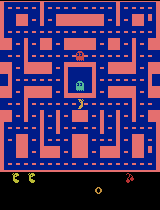

Episode 826/2500 | score 2830 | recent mean 1242.0 | exploration 10%


Episode 827/2500 | score 1350 | recent mean 1216.8 | exploration 10%


Episode 828/2500 | score 720 | recent mean 1196.8 | exploration 10%


Episode 829/2500 | score 1010 | recent mean 1212.8 | exploration 10%


Episode 830/2500 | score 440 | recent mean 1176.8 | exploration 10%


...

Episode 848/2500 | score 1380 | recent mean 1435.6 | exploration 10%


Episode 849/2500 | score 930 | recent mean 1412.8 | exploration 10%


Progress | 849/2500 complete games | 645,000 decisions | 158,751 updates | 61.3 min


Episode 850/2500 | score 1230 | recent mean 1434.0 | exploration 10%


Separate demonstration score: 1090.0
After 850 training games | 4× playback | 2 plays | first 20s of game time


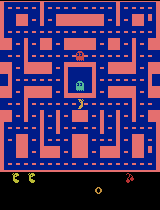

Episode 851/2500 | score 510 | recent mean 1341.2 | exploration 10%


Episode 852/2500 | score 1540 | recent mean 1348.8 | exploration 10%


Episode 853/2500 | score 2280 | recent mean 1411.2 | exploration 10%


Episode 854/2500 | score 1040 | recent mean 1412.4 | exploration 10%


Episode 855/2500 | score 1170 | recent mean 1441.6 | exploration 10%


...

Episode 873/2500 | score 1810 | recent mean 1460.0 | exploration 10%


Episode 874/2500 | score 1860 | recent mean 1497.2 | exploration 10%


Progress | 874/2500 complete games | 665,000 decisions | 163,751 updates | 62.6 min


Episode 875/2500 | score 1460 | recent mean 1506.4 | exploration 10%


Separate demonstration score: 1500.0
After 875 training games | 4× playback | 2 plays | first 20s of game time


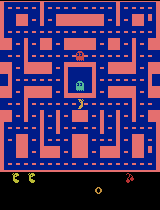

Episode 876/2500 | score 820 | recent mean 1518.8 | exploration 10%


Episode 877/2500 | score 630 | recent mean 1482.4 | exploration 10%


Episode 878/2500 | score 2470 | recent mean 1490.0 | exploration 10%


Episode 879/2500 | score 2260 | recent mean 1538.8 | exploration 10%


Episode 880/2500 | score 640 | recent mean 1517.6 | exploration 10%


...

Episode 898/2500 | score 780 | recent mean 1410.8 | exploration 10%


Episode 899/2500 | score 730 | recent mean 1365.6 | exploration 10%


Progress | 899/2500 complete games | 685,000 decisions | 168,751 updates | 63.8 min


Episode 900/2500 | score 630 | recent mean 1332.4 | exploration 10%


Separate demonstration score: 900.0
After 900 training games | 4× playback | 2 plays | first 20s of game time


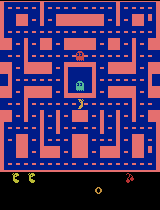

Episode 901/2500 | score 970 | recent mean 1338.4 | exploration 10%


Episode 902/2500 | score 860 | recent mean 1347.6 | exploration 10%


Episode 903/2500 | score 1310 | recent mean 1301.2 | exploration 10%


Episode 904/2500 | score 1290 | recent mean 1262.4 | exploration 10%


Episode 905/2500 | score 1370 | recent mean 1291.6 | exploration 10%


...

Episode 922/2500 | score 2010 | recent mean 1347.6 | exploration 10%


Episode 923/2500 | score 1020 | recent mean 1357.2 | exploration 10%


Episode 924/2500 | score 1610 | recent mean 1392.4 | exploration 10%


Episode 925/2500 | score 1290 | recent mean 1418.8 | exploration 10%


Separate demonstration score: 1000.0
After 925 training games | 4× playback | 2 plays | first 20s of game time


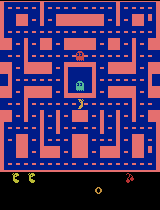

Episode 926/2500 | score 1140 | recent mean 1425.6 | exploration 10%


Progress | 926/2500 complete games | 705,000 decisions | 173,751 updates | 65.1 min


Episode 927/2500 | score 650 | recent mean 1417.2 | exploration 10%


Episode 928/2500 | score 420 | recent mean 1381.6 | exploration 10%


Episode 929/2500 | score 2990 | recent mean 1449.6 | exploration 10%


...

Episode 948/2500 | score 1700 | recent mean 1408.8 | exploration 10%


Progress | 948/2500 complete games | 720,000 decisions | 177,501 updates | 66.1 min


Episode 949/2500 | score 2190 | recent mean 1432.0 | exploration 10%


Episode 950/2500 | score 880 | recent mean 1415.6 | exploration 10%


Separate demonstration score: 1090.0
After 950 training games | 4× playback | 2 plays | first 20s of game time


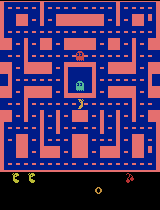

Episode 951/2500 | score 1170 | recent mean 1416.8 | exploration 10%


Episode 952/2500 | score 1210 | recent mean 1439.2 | exploration 10%


Episode 953/2500 | score 700 | recent mean 1450.4 | exploration 10%


Episode 954/2500 | score 1800 | recent mean 1402.8 | exploration 10%


Progress | 954/2500 complete games | 725,000 decisions | 178,751 updates | 66.4 min


...

Progress | 972/2500 complete games | 740,000 decisions | 182,501 updates | 67.3 min


Episode 973/2500 | score 1640 | recent mean 1514.4 | exploration 10%


Episode 974/2500 | score 1670 | recent mean 1493.6 | exploration 10%


Episode 975/2500 | score 1600 | recent mean 1522.4 | exploration 10%


Separate demonstration score: 670.0
After 975 training games | 4× playback | 2 plays | first 20s of game time


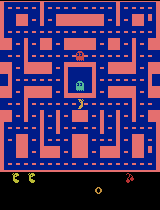

Episode 976/2500 | score 700 | recent mean 1503.6 | exploration 10%


Episode 977/2500 | score 2330 | recent mean 1548.4 | exploration 10%


Episode 978/2500 | score 1850 | recent mean 1594.4 | exploration 10%


Episode 979/2500 | score 1290 | recent mean 1574.0 | exploration 10%


Progress | 979/2500 complete games | 745,000 decisions | 183,751 updates | 67.7 min


...

Episode 997/2500 | score 2120 | recent mean 1464.0 | exploration 10%


Episode 998/2500 | score 2330 | recent mean 1491.6 | exploration 10%


Episode 999/2500 | score 2100 | recent mean 1508.8 | exploration 10%


Episode 1000/2500 | score 2350 | recent mean 1538.8 | exploration 10%


Separate demonstration score: 2470.0
After 1000 training games | 4× playback | 2 plays | first 20s of game time


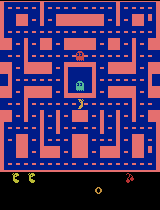

Validation candidate after 1000 additional games (periodic)...


Validation scores [1490.0, 3130.0, 1980.0, 1900.0, 810.0, 2640.0, 430.0, 1130.0, 790.0, 2810.0] | mean 1711.0 | selection metric 1267.2 | new selected model: True


Episode 1001/2500 | score 2160 | recent mean 1597.2 | exploration 10%


Episode 1002/2500 | score 1290 | recent mean 1555.6 | exploration 10%


Episode 1003/2500 | score 1290 | recent mean 1533.2 | exploration 10%


...

Episode 1023/2500 | score 810 | recent mean 1393.2 | exploration 10%


Episode 1024/2500 | score 1880 | recent mean 1384.4 | exploration 10%


Progress | 1024/2500 complete games | 780,000 decisions | 192,501 updates | 70.1 min


Episode 1025/2500 | score 1230 | recent mean 1339.6 | exploration 10%


Separate demonstration score: 1390.0
After 1025 training games | 4× playback | 2 plays | first 20s of game time


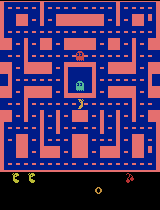

Episode 1026/2500 | score 2520 | recent mean 1354.0 | exploration 10%


Episode 1027/2500 | score 1590 | recent mean 1366.0 | exploration 10%


Episode 1028/2500 | score 790 | recent mean 1346.0 | exploration 10%


Episode 1029/2500 | score 650 | recent mean 1313.6 | exploration 10%


Progress | 1029/2500 complete games | 785,000 decisions | 193,751 updates | 70.4 min


...

Episode 1047/2500 | score 920 | recent mean 1442.4 | exploration 10%


Episode 1048/2500 | score 1390 | recent mean 1465.6 | exploration 10%


Episode 1049/2500 | score 810 | recent mean 1422.8 | exploration 10%


Episode 1050/2500 | score 1690 | recent mean 1441.2 | exploration 10%


Separate demonstration score: 2490.0
After 1050 training games | 4× playback | 2 plays | first 20s of game time


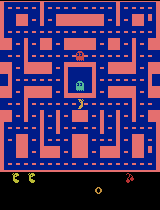

Episode 1051/2500 | score 630 | recent mean 1365.6 | exploration 10%


Progress | 1051/2500 complete games | 800,000 decisions | 197,501 updates | 71.4 min


Episode 1052/2500 | score 1320 | recent mean 1354.8 | exploration 10%


Episode 1053/2500 | score 2680 | recent mean 1430.4 | exploration 10%


Episode 1054/2500 | score 1570 | recent mean 1467.2 | exploration 10%


...

Episode 1073/2500 | score 2540 | recent mean 1877.2 | exploration 10%


Episode 1074/2500 | score 2340 | recent mean 1938.4 | exploration 10%


Progress | 1074/2500 complete games | 820,000 decisions | 202,501 updates | 72.6 min


Episode 1075/2500 | score 1590 | recent mean 1934.4 | exploration 10%


Separate demonstration score: 1780.0
After 1075 training games | 4× playback | 2 plays | first 20s of game time


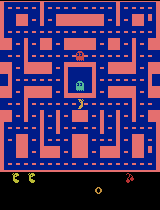

Episode 1076/2500 | score 1650 | recent mean 1975.2 | exploration 10%


Episode 1077/2500 | score 2520 | recent mean 2023.2 | exploration 10%


Episode 1078/2500 | score 1670 | recent mean 1982.8 | exploration 10%


Episode 1079/2500 | score 590 | recent mean 1943.6 | exploration 10%


Episode 1080/2500 | score 1180 | recent mean 1932.0 | exploration 10%


...

Episode 1097/2500 | score 4320 | recent mean 2002.4 | exploration 10%


Episode 1098/2500 | score 1300 | recent mean 1952.8 | exploration 10%


Episode 1099/2500 | score 1500 | recent mean 1919.2 | exploration 10%


Episode 1100/2500 | score 1680 | recent mean 1922.8 | exploration 10%


Separate demonstration score: 1480.0
After 1100 training games | 4× playback | 2 plays | first 20s of game time


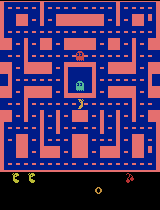

Progress | 1100/2500 complete games | 840,000 decisions | 207,501 updates | 73.9 min


Episode 1101/2500 | score 2700 | recent mean 1964.8 | exploration 10%


Episode 1102/2500 | score 920 | recent mean 1900.8 | exploration 10%


Episode 1103/2500 | score 2150 | recent mean 1920.0 | exploration 10%


Episode 1104/2500 | score 1810 | recent mean 1968.8 | exploration 10%


...

Episode 1122/2500 | score 1440 | recent mean 1483.6 | exploration 10%


Episode 1123/2500 | score 4130 | recent mean 1596.8 | exploration 10%


Episode 1124/2500 | score 2730 | recent mean 1646.0 | exploration 10%


Episode 1125/2500 | score 2550 | recent mean 1680.8 | exploration 10%


Separate demonstration score: 1820.0
After 1125 training games | 4× playback | 2 plays | first 20s of game time


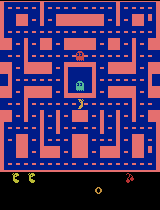

Progress | 1125/2500 complete games | 860,000 decisions | 212,501 updates | 75.1 min


Episode 1126/2500 | score 1260 | recent mean 1623.2 | exploration 10%


Episode 1127/2500 | score 2400 | recent mean 1682.4 | exploration 10%


Episode 1128/2500 | score 1750 | recent mean 1666.4 | exploration 10%


Episode 1129/2500 | score 3160 | recent mean 1720.4 | exploration 10%


...

Episode 1147/2500 | score 1640 | recent mean 1851.6 | exploration 10%


Episode 1148/2500 | score 1710 | recent mean 1754.8 | exploration 10%


Episode 1149/2500 | score 630 | recent mean 1670.8 | exploration 10%


Episode 1150/2500 | score 560 | recent mean 1591.2 | exploration 10%


Separate demonstration score: 1310.0
After 1150 training games | 4× playback | 2 plays | first 20s of game time


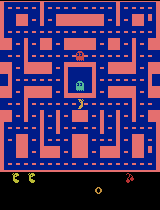

Episode 1151/2500 | score 2760 | recent mean 1651.2 | exploration 10%


Progress | 1151/2500 complete games | 880,000 decisions | 217,501 updates | 76.4 min


Episode 1152/2500 | score 830 | recent mean 1588.4 | exploration 10%


Episode 1153/2500 | score 1170 | recent mean 1565.2 | exploration 10%


Episode 1154/2500 | score 1100 | recent mean 1482.8 | exploration 10%


...

Episode 1172/2500 | score 1320 | recent mean 1474.8 | exploration 10%


Episode 1173/2500 | score 1690 | recent mean 1474.0 | exploration 10%


Episode 1174/2500 | score 1670 | recent mean 1515.6 | exploration 10%


Episode 1175/2500 | score 400 | recent mean 1509.2 | exploration 10%


Separate demonstration score: 1190.0
After 1175 training games | 4× playback | 2 plays | first 20s of game time


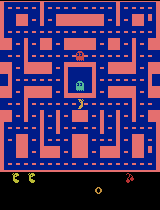

Episode 1176/2500 | score 1140 | recent mean 1444.4 | exploration 10%


Episode 1177/2500 | score 1460 | recent mean 1469.6 | exploration 10%


Episode 1178/2500 | score 2930 | recent mean 1540.0 | exploration 10%


Progress | 1178/2500 complete games | 900,000 decisions | 222,501 updates | 77.7 min


Episode 1179/2500 | score 1740 | recent mean 1565.6 | exploration 10%


...

Episode 1198/2500 | score 2800 | recent mean 1780.4 | exploration 10%


Episode 1199/2500 | score 790 | recent mean 1745.2 | exploration 10%


Episode 1200/2500 | score 1000 | recent mean 1769.2 | exploration 10%


Separate demonstration score: 1720.0


After 1200 training games | 4× playback | 2 plays | first 20s of game time


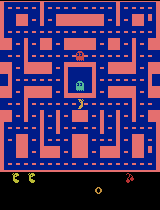

Episode 1201/2500 | score 2890 | recent mean 1839.2 | exploration 10%


Progress | 1201/2500 complete games | 920,000 decisions | 227,501 updates | 79.0 min


Episode 1202/2500 | score 2450 | recent mean 1878.8 | exploration 10%


Episode 1203/2500 | score 1360 | recent mean 1816.0 | exploration 10%


Episode 1204/2500 | score 4500 | recent mean 1926.4 | exploration 10%


...

Episode 1222/2500 | score 2880 | recent mean 2069.2 | exploration 10%


Episode 1223/2500 | score 550 | recent mean 1979.2 | exploration 10%


Episode 1224/2500 | score 1050 | recent mean 1989.6 | exploration 10%


Episode 1225/2500 | score 1430 | recent mean 2006.8 | exploration 10%


Separate demonstration score: 2420.0
After 1225 training games | 4× playback | 2 plays | first 20s of game time


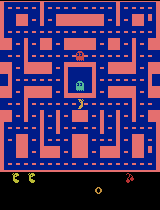

Episode 1226/2500 | score 1260 | recent mean 1941.6 | exploration 10%


Episode 1227/2500 | score 1420 | recent mean 1900.4 | exploration 10%


Episode 1228/2500 | score 3040 | recent mean 1967.6 | exploration 10%


Progress | 1228/2500 complete games | 940,000 decisions | 232,501 updates | 80.3 min


Episode 1229/2500 | score 1630 | recent mean 1852.8 | exploration 10%


...

Episode 1248/2500 | score 2310 | recent mean 1560.8 | exploration 10%


Episode 1249/2500 | score 2550 | recent mean 1620.8 | exploration 10%


Episode 1250/2500 | score 3690 | recent mean 1711.2 | exploration 10%


Separate demonstration score: 2500.0


After 1250 training games | 4× playback | 2 plays | first 20s of game time


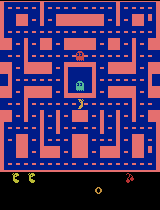

Validation candidate after 1250 additional games (periodic)...


Validation scores [2930.0, 1560.0, 2700.0, 1770.0, 410.0, 2440.0, 3810.0, 1640.0, 1570.0, 3240.0] | mean 2207.0 | selection metric 1732.1 | new selected model: True


Episode 1251/2500 | score 3370 | recent mean 1795.6 | exploration 10%


Episode 1252/2500 | score 1400 | recent mean 1794.8 | exploration 10%


Episode 1253/2500 | score 2360 | recent mean 1767.6 | exploration 10%


...

Episode 1273/2500 | score 1840 | recent mean 1769.2 | exploration 10%


Progress | 1273/2500 complete games | 975,000 decisions | 241,251 updates | 82.8 min


Episode 1274/2500 | score 720 | recent mean 1696.0 | exploration 10%


Episode 1275/2500 | score 1780 | recent mean 1619.6 | exploration 10%


Separate demonstration score: 2090.0
After 1275 training games | 4× playback | 2 plays | first 20s of game time


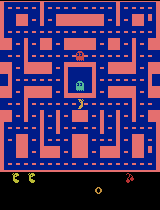

Episode 1276/2500 | score 390 | recent mean 1500.4 | exploration 10%


Episode 1277/2500 | score 1500 | recent mean 1504.4 | exploration 10%


Episode 1278/2500 | score 1360 | recent mean 1464.4 | exploration 10%


Episode 1279/2500 | score 1620 | recent mean 1510.0 | exploration 10%


Episode 1280/2500 | score 2020 | recent mean 1498.0 | exploration 10%


...

Episode 1298/2500 | score 2330 | recent mean 1629.2 | exploration 10%


Episode 1299/2500 | score 1440 | recent mean 1658.0 | exploration 10%


Progress | 1299/2500 complete games | 995,000 decisions | 246,251 updates | 84.1 min


Episode 1300/2500 | score 1050 | recent mean 1628.8 | exploration 10%


Separate demonstration score: 2930.0
After 1300 training games | 4× playback | 2 plays | first 20s of game time


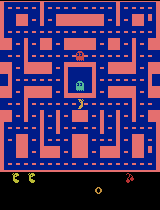

Episode 1301/2500 | score 860 | recent mean 1647.6 | exploration 10%


Episode 1302/2500 | score 3100 | recent mean 1711.6 | exploration 10%


Episode 1303/2500 | score 1270 | recent mean 1708.0 | exploration 10%


Episode 1304/2500 | score 950 | recent mean 1681.2 | exploration 10%


Progress | 1304/2500 complete games | 1,000,000 decisions | 247,501 updates | 84.5 min


...

Episode 1322/2500 | score 2960 | recent mean 1955.2 | exploration 10%


Episode 1323/2500 | score 4220 | recent mean 2030.8 | exploration 10%


Episode 1324/2500 | score 3200 | recent mean 2101.2 | exploration 10%


Episode 1325/2500 | score 1120 | recent mean 2104.0 | exploration 10%


Separate demonstration score: 1820.0
After 1325 training games | 4× playback | 2 plays | first 20s of game time


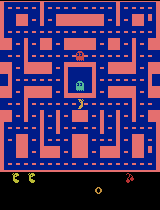

Episode 1326/2500 | score 2430 | recent mean 2166.8 | exploration 10%


Episode 1327/2500 | score 4200 | recent mean 2210.8 | exploration 10%


Episode 1328/2500 | score 2530 | recent mean 2261.2 | exploration 10%


Progress | 1328/2500 complete games | 1,020,000 decisions | 252,501 updates | 85.8 min


Episode 1329/2500 | score 3340 | recent mean 2356.8 | exploration 10%


...

Episode 1347/2500 | score 1900 | recent mean 2260.8 | exploration 10%


Episode 1348/2500 | score 3030 | recent mean 2213.2 | exploration 10%


Episode 1349/2500 | score 500 | recent mean 2105.2 | exploration 10%


Episode 1350/2500 | score 1740 | recent mean 2130.0 | exploration 10%


Separate demonstration score: 1750.0
After 1350 training games | 4× playback | 2 plays | first 20s of game time


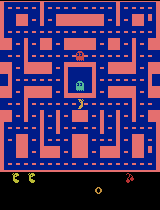

Episode 1351/2500 | score 1980 | recent mean 2112.0 | exploration 10%


Episode 1352/2500 | score 1330 | recent mean 1997.2 | exploration 10%


Episode 1353/2500 | score 1410 | recent mean 1952.4 | exploration 10%


Episode 1354/2500 | score 1380 | recent mean 1874.0 | exploration 10%


Progress | 1354/2500 complete games | 1,040,000 decisions | 257,501 updates | 87.1 min


...

Episode 1373/2500 | score 670 | recent mean 1365.2 | exploration 10%


Progress | 1373/2500 complete games | 1,055,000 decisions | 261,251 updates | 88.0 min


Episode 1374/2500 | score 1530 | recent mean 1406.4 | exploration 10%


Episode 1375/2500 | score 1180 | recent mean 1384.0 | exploration 10%


Separate demonstration score: 1490.0
After 1375 training games | 4× playback | 2 plays | first 20s of game time


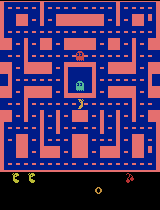

Episode 1376/2500 | score 1470 | recent mean 1363.6 | exploration 10%


Episode 1377/2500 | score 1220 | recent mean 1359.2 | exploration 10%


Episode 1378/2500 | score 1020 | recent mean 1343.6 | exploration 10%


Episode 1379/2500 | score 1430 | recent mean 1345.6 | exploration 10%


Episode 1380/2500 | score 670 | recent mean 1314.4 | exploration 10%


...

Episode 1397/2500 | score 1460 | recent mean 1338.4 | exploration 10%


Episode 1398/2500 | score 3190 | recent mean 1439.2 | exploration 10%


Episode 1399/2500 | score 880 | recent mean 1413.2 | exploration 10%


Episode 1400/2500 | score 630 | recent mean 1391.2 | exploration 10%


Separate demonstration score: 2540.0
After 1400 training games | 4× playback | 2 plays | first 20s of game time


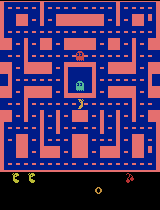

Progress | 1400/2500 complete games | 1,075,000 decisions | 266,251 updates | 89.4 min


Episode 1401/2500 | score 1020 | recent mean 1373.2 | exploration 10%


Episode 1402/2500 | score 760 | recent mean 1354.8 | exploration 10%


Episode 1403/2500 | score 3450 | recent mean 1452.0 | exploration 10%


Episode 1404/2500 | score 2090 | recent mean 1478.4 | exploration 10%


...

Episode 1422/2500 | score 1150 | recent mean 1452.0 | exploration 10%


Episode 1423/2500 | score 950 | recent mean 1362.4 | exploration 10%


Episode 1424/2500 | score 2460 | recent mean 1425.6 | exploration 10%


Episode 1425/2500 | score 990 | recent mean 1440.0 | exploration 10%


Separate demonstration score: 2070.0
After 1425 training games | 4× playback | 2 plays | first 20s of game time


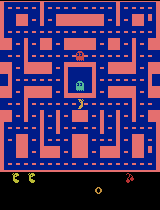

Episode 1426/2500 | score 1000 | recent mean 1439.2 | exploration 10%


Progress | 1426/2500 complete games | 1,095,000 decisions | 271,251 updates | 90.6 min


Episode 1427/2500 | score 1260 | recent mean 1459.2 | exploration 10%


Episode 1428/2500 | score 2620 | recent mean 1426.0 | exploration 10%


Episode 1429/2500 | score 1200 | recent mean 1390.4 | exploration 10%


...

Episode 1447/2500 | score 1520 | recent mean 1486.4 | exploration 10%


Episode 1448/2500 | score 2490 | recent mean 1548.0 | exploration 10%


Episode 1449/2500 | score 2630 | recent mean 1554.8 | exploration 10%


Episode 1450/2500 | score 1940 | recent mean 1592.8 | exploration 10%


Separate demonstration score: 2940.0
After 1450 training games | 4× playback | 2 plays | first 20s of game time


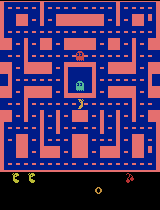

Episode 1451/2500 | score 4180 | recent mean 1720.0 | exploration 10%


Progress | 1451/2500 complete games | 1,115,000 decisions | 276,251 updates | 91.9 min


Episode 1452/2500 | score 2940 | recent mean 1787.2 | exploration 10%


Episode 1453/2500 | score 1180 | recent mean 1729.6 | exploration 10%


Episode 1454/2500 | score 980 | recent mean 1720.8 | exploration 10%


...

Episode 1472/2500 | score 1160 | recent mean 2138.8 | exploration 10%


Episode 1473/2500 | score 1560 | recent mean 2101.6 | exploration 10%


Episode 1474/2500 | score 2040 | recent mean 2078.0 | exploration 10%


Episode 1475/2500 | score 1100 | recent mean 2044.4 | exploration 10%


Separate demonstration score: 1610.0
After 1475 training games | 4× playback | 2 plays | first 20s of game time


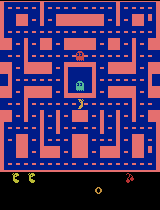

Progress | 1475/2500 complete games | 1,135,000 decisions | 281,251 updates | 93.2 min


Episode 1476/2500 | score 1380 | recent mean 1932.4 | exploration 10%


Episode 1477/2500 | score 2140 | recent mean 1900.4 | exploration 10%


Episode 1478/2500 | score 2370 | recent mean 1948.0 | exploration 10%


Episode 1479/2500 | score 1180 | recent mean 1956.0 | exploration 10%


...

Episode 1498/2500 | score 1030 | recent mean 1826.8 | exploration 10%


Progress | 1498/2500 complete games | 1,155,000 decisions | 286,251 updates | 94.5 min


Episode 1499/2500 | score 2450 | recent mean 1843.2 | exploration 10%


Episode 1500/2500 | score 1580 | recent mean 1862.4 | exploration 10%


Separate demonstration score: 2370.0
After 1500 training games | 4× playback | 2 plays | first 20s of game time


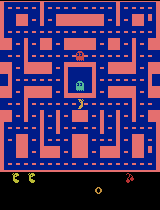

Validation candidate after 1500 additional games (periodic)...


Validation scores [890.0, 700.0, 1050.0, 1240.0, 760.0, 2000.0, 970.0, 1750.0, 2980.0, 1040.0] | mean 1338.0 | selection metric 1000.3 | new selected model: False


Episode 1501/2500 | score 1730 | recent mean 1876.4 | exploration 10%


Episode 1502/2500 | score 930 | recent mean 1828.0 | exploration 10%


Episode 1503/2500 | score 2700 | recent mean 1841.2 | exploration 10%


...

Episode 1522/2500 | score 1000 | recent mean 1607.6 | exploration 10%


Episode 1523/2500 | score 560 | recent mean 1588.8 | exploration 10%


Episode 1524/2500 | score 750 | recent mean 1520.8 | exploration 10%


Episode 1525/2500 | score 1680 | recent mean 1524.8 | exploration 10%


Separate demonstration score: 1710.0
After 1525 training games | 4× playback | 2 plays | first 20s of game time


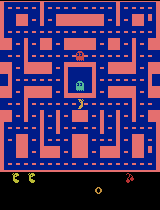

Progress | 1525/2500 complete games | 1,175,000 decisions | 291,251 updates | 96.1 min


Episode 1526/2500 | score 2060 | recent mean 1538.0 | exploration 10%


Episode 1527/2500 | score 2250 | recent mean 1590.8 | exploration 10%


Episode 1528/2500 | score 1150 | recent mean 1528.8 | exploration 10%


Episode 1529/2500 | score 760 | recent mean 1498.0 | exploration 10%


...

Episode 1548/2500 | score 1580 | recent mean 1591.2 | exploration 10%


Episode 1549/2500 | score 980 | recent mean 1600.4 | exploration 10%


Progress | 1549/2500 complete games | 1,195,000 decisions | 296,251 updates | 97.4 min


Episode 1550/2500 | score 1700 | recent mean 1601.2 | exploration 10%


Separate demonstration score: 2620.0
After 1550 training games | 4× playback | 2 plays | first 20s of game time


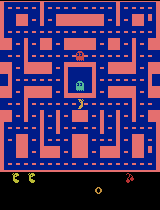

Episode 1551/2500 | score 1820 | recent mean 1591.6 | exploration 10%


Episode 1552/2500 | score 1240 | recent mean 1551.2 | exploration 10%


Episode 1553/2500 | score 1670 | recent mean 1572.0 | exploration 10%


Episode 1554/2500 | score 720 | recent mean 1570.4 | exploration 10%


Episode 1555/2500 | score 2940 | recent mean 1599.2 | exploration 10%


...

Episode 1572/2500 | score 800 | recent mean 1679.6 | exploration 10%


Episode 1573/2500 | score 1610 | recent mean 1680.8 | exploration 10%


Episode 1574/2500 | score 1080 | recent mean 1684.8 | exploration 10%


Episode 1575/2500 | score 1270 | recent mean 1667.6 | exploration 10%


Separate demonstration score: 1320.0
After 1575 training games | 4× playback | 2 plays | first 20s of game time


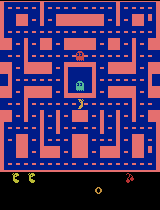

Progress | 1575/2500 complete games | 1,215,000 decisions | 301,251 updates | 98.7 min


Episode 1576/2500 | score 1830 | recent mean 1668.0 | exploration 10%


Episode 1577/2500 | score 1910 | recent mean 1694.8 | exploration 10%


Episode 1578/2500 | score 2350 | recent mean 1722.0 | exploration 10%


Episode 1579/2500 | score 1320 | recent mean 1746.0 | exploration 10%


...

Episode 1598/2500 | score 1250 | recent mean 1722.4 | exploration 10%


Episode 1599/2500 | score 1270 | recent mean 1730.0 | exploration 10%


Progress | 1599/2500 complete games | 1,235,000 decisions | 306,251 updates | 99.9 min


Episode 1600/2500 | score 1020 | recent mean 1720.0 | exploration 10%


Separate demonstration score: 1760.0
After 1600 training games | 4× playback | 2 plays | first 20s of game time


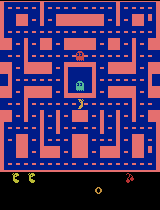

Episode 1601/2500 | score 910 | recent mean 1683.2 | exploration 10%


Episode 1602/2500 | score 1630 | recent mean 1672.0 | exploration 10%


Episode 1603/2500 | score 3200 | recent mean 1706.0 | exploration 10%


Episode 1604/2500 | score 870 | recent mean 1688.0 | exploration 10%


Episode 1605/2500 | score 3130 | recent mean 1786.4 | exploration 10%


...

Episode 1623/2500 | score 2660 | recent mean 1518.0 | exploration 10%


Episode 1624/2500 | score 2480 | recent mean 1566.4 | exploration 10%


Progress | 1624/2500 complete games | 1,255,000 decisions | 311,251 updates | 101.1 min


Episode 1625/2500 | score 2820 | recent mean 1638.4 | exploration 10%


Separate demonstration score: 2280.0
After 1625 training games | 4× playback | 2 plays | first 20s of game time


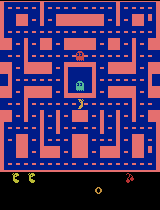

Episode 1626/2500 | score 2500 | recent mean 1702.0 | exploration 10%


Episode 1627/2500 | score 1330 | recent mean 1690.0 | exploration 10%


Episode 1628/2500 | score 2860 | recent mean 1676.4 | exploration 10%


Episode 1629/2500 | score 1860 | recent mean 1716.0 | exploration 10%


Episode 1630/2500 | score 600 | recent mean 1614.8 | exploration 10%


...

Episode 1648/2500 | score 2660 | recent mean 1790.0 | exploration 10%


Episode 1649/2500 | score 890 | recent mean 1726.4 | exploration 10%


Progress | 1649/2500 complete games | 1,275,000 decisions | 316,251 updates | 102.4 min


Episode 1650/2500 | score 1890 | recent mean 1689.2 | exploration 10%


Separate demonstration score: 4460.0
After 1650 training games | 4× playback | 2 plays | first 20s of game time


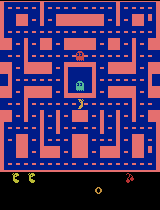

Episode 1651/2500 | score 570 | recent mean 1612.0 | exploration 10%


Episode 1652/2500 | score 1980 | recent mean 1638.0 | exploration 10%


Episode 1653/2500 | score 1660 | recent mean 1590.0 | exploration 10%


Episode 1654/2500 | score 980 | recent mean 1554.8 | exploration 10%


Episode 1655/2500 | score 1400 | recent mean 1586.8 | exploration 10%


...

Progress | 1672/2500 complete games | 1,295,000 decisions | 321,251 updates | 103.7 min


Episode 1673/2500 | score 3010 | recent mean 1735.2 | exploration 10%


Episode 1674/2500 | score 2520 | recent mean 1800.4 | exploration 10%


Episode 1675/2500 | score 1570 | recent mean 1787.6 | exploration 10%


Separate demonstration score: 1840.0
After 1675 training games | 4× playback | 2 plays | first 20s of game time


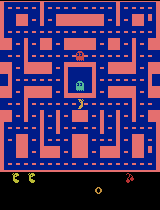

Episode 1676/2500 | score 1650 | recent mean 1830.8 | exploration 10%


Episode 1677/2500 | score 2160 | recent mean 1838.0 | exploration 10%


Episode 1678/2500 | score 2010 | recent mean 1852.0 | exploration 10%


Progress | 1678/2500 complete games | 1,300,000 decisions | 322,501 updates | 104.0 min


Episode 1679/2500 | score 1950 | recent mean 1890.8 | exploration 10%


...

Progress | 1697/2500 complete games | 1,315,000 decisions | 326,251 updates | 105.0 min


Episode 1698/2500 | score 2190 | recent mean 1937.2 | exploration 10%


Episode 1699/2500 | score 1410 | recent mean 1892.8 | exploration 10%


Episode 1700/2500 | score 670 | recent mean 1856.8 | exploration 10%


Separate demonstration score: 1020.0
After 1700 training games | 4× playback | 2 plays | first 20s of game time


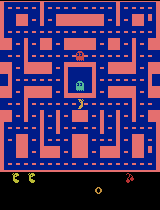

Episode 1701/2500 | score 1570 | recent mean 1853.6 | exploration 10%


Episode 1702/2500 | score 840 | recent mean 1800.8 | exploration 10%


Episode 1703/2500 | score 1930 | recent mean 1797.6 | exploration 10%


Episode 1704/2500 | score 2040 | recent mean 1801.2 | exploration 10%


Progress | 1704/2500 complete games | 1,320,000 decisions | 327,501 updates | 105.4 min


...

Episode 1723/2500 | score 1070 | recent mean 1773.2 | exploration 10%


Progress | 1723/2500 complete games | 1,335,000 decisions | 331,251 updates | 106.4 min


Episode 1724/2500 | score 1630 | recent mean 1782.0 | exploration 10%


Episode 1725/2500 | score 1160 | recent mean 1801.6 | exploration 10%


Separate demonstration score: 3080.0
After 1725 training games | 4× playback | 2 plays | first 20s of game time


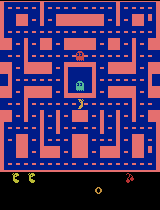

Episode 1726/2500 | score 3280 | recent mean 1870.0 | exploration 10%


Episode 1727/2500 | score 2710 | recent mean 1944.8 | exploration 10%


Episode 1728/2500 | score 980 | recent mean 1906.8 | exploration 10%


Progress | 1728/2500 complete games | 1,340,000 decisions | 332,501 updates | 106.7 min


Episode 1729/2500 | score 3900 | recent mean 1981.2 | exploration 10%


...

Progress | 1748/2500 complete games | 1,355,000 decisions | 336,251 updates | 107.7 min


Episode 1749/2500 | score 2020 | recent mean 1808.4 | exploration 10%


Episode 1750/2500 | score 750 | recent mean 1792.0 | exploration 10%


Separate demonstration score: 930.0


After 1750 training games | 4× playback | 2 plays | first 20s of game time


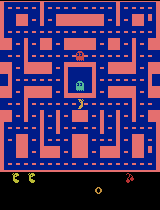

Validation candidate after 1750 additional games (periodic)...


Validation scores [1860.0, 2750.0, 1280.0, 2440.0, 710.0, 1740.0, 480.0, 1320.0, 4630.0, 2120.0] | mean 1933.0 | selection metric 1369.9 | new selected model: False


Episode 1751/2500 | score 1550 | recent mean 1722.8 | exploration 10%


Episode 1752/2500 | score 690 | recent mean 1642.0 | exploration 10%


Episode 1753/2500 | score 1150 | recent mean 1648.8 | exploration 10%


...

Episode 1773/2500 | score 1750 | recent mean 1761.2 | exploration 10%


Progress | 1773/2500 complete games | 1,375,000 decisions | 341,251 updates | 109.2 min


Episode 1774/2500 | score 1070 | recent mean 1723.2 | exploration 10%


Episode 1775/2500 | score 910 | recent mean 1729.6 | exploration 10%


Separate demonstration score: 1510.0
After 1775 training games | 4× playback | 2 plays | first 20s of game time


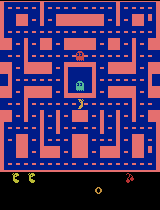

Episode 1776/2500 | score 3010 | recent mean 1788.0 | exploration 10%


Episode 1777/2500 | score 2590 | recent mean 1864.0 | exploration 10%


Episode 1778/2500 | score 880 | recent mean 1853.2 | exploration 10%


Episode 1779/2500 | score 1130 | recent mean 1776.8 | exploration 10%


Progress | 1779/2500 complete games | 1,380,000 decisions | 342,501 updates | 109.6 min


...

Episode 1798/2500 | score 2230 | recent mean 1514.0 | exploration 10%


Episode 1799/2500 | score 1340 | recent mean 1524.8 | exploration 10%


Progress | 1799/2500 complete games | 1,395,000 decisions | 346,251 updates | 110.6 min


Episode 1800/2500 | score 700 | recent mean 1516.4 | exploration 10%


Separate demonstration score: 1700.0
After 1800 training games | 4× playback | 2 plays | first 20s of game time


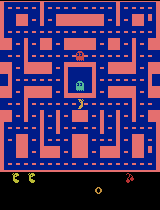

Episode 1801/2500 | score 1090 | recent mean 1439.6 | exploration 10%


Episode 1802/2500 | score 720 | recent mean 1364.8 | exploration 10%


Episode 1803/2500 | score 830 | recent mean 1362.8 | exploration 10%


Episode 1804/2500 | score 1200 | recent mean 1365.6 | exploration 10%


Episode 1805/2500 | score 2150 | recent mean 1308.4 | exploration 10%


...

Episode 1822/2500 | score 1320 | recent mean 1532.4 | exploration 10%


Episode 1823/2500 | score 880 | recent mean 1478.4 | exploration 10%


Episode 1824/2500 | score 1200 | recent mean 1472.8 | exploration 10%


Episode 1825/2500 | score 2090 | recent mean 1528.4 | exploration 10%


Separate demonstration score: 1160.0
After 1825 training games | 4× playback | 2 plays | first 20s of game time


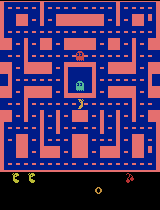

Episode 1826/2500 | score 1250 | recent mean 1534.8 | exploration 10%


Progress | 1826/2500 complete games | 1,415,000 decisions | 351,251 updates | 112.0 min


Episode 1827/2500 | score 1450 | recent mean 1564.0 | exploration 10%


Episode 1828/2500 | score 1320 | recent mean 1583.6 | exploration 10%


Episode 1829/2500 | score 1620 | recent mean 1600.4 | exploration 10%


...

Progress | 1847/2500 complete games | 1,435,000 decisions | 356,251 updates | 113.3 min


Episode 1848/2500 | score 860 | recent mean 1868.4 | exploration 10%


Episode 1849/2500 | score 2340 | recent mean 1914.0 | exploration 10%


Episode 1850/2500 | score 2370 | recent mean 1925.2 | exploration 10%


Separate demonstration score: 1000.0
After 1850 training games | 4× playback | 2 plays | first 20s of game time


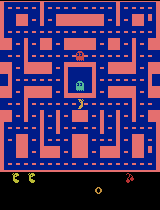

Episode 1851/2500 | score 820 | recent mean 1908.0 | exploration 10%


Episode 1852/2500 | score 560 | recent mean 1872.4 | exploration 10%


Episode 1853/2500 | score 3310 | recent mean 1952.0 | exploration 10%


Episode 1854/2500 | score 1770 | recent mean 1958.0 | exploration 10%


Progress | 1854/2500 complete games | 1,440,000 decisions | 357,501 updates | 113.7 min


...

Episode 1873/2500 | score 730 | recent mean 1954.0 | exploration 10%


Progress | 1873/2500 complete games | 1,455,000 decisions | 361,251 updates | 114.6 min


Episode 1874/2500 | score 3350 | recent mean 1994.4 | exploration 10%


Episode 1875/2500 | score 770 | recent mean 1930.4 | exploration 10%


Separate demonstration score: 720.0
After 1875 training games | 4× playback | 2 plays | first 20s of game time


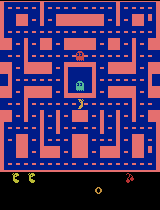

Episode 1876/2500 | score 950 | recent mean 1935.6 | exploration 10%


Episode 1877/2500 | score 3250 | recent mean 2043.2 | exploration 10%


Episode 1878/2500 | score 1490 | recent mean 1970.4 | exploration 10%


Episode 1879/2500 | score 2530 | recent mean 2000.8 | exploration 10%


Progress | 1879/2500 complete games | 1,460,000 decisions | 362,501 updates | 115.0 min


...

Episode 1897/2500 | score 1330 | recent mean 1768.4 | exploration 10%


Episode 1898/2500 | score 1150 | recent mean 1785.2 | exploration 10%


Episode 1899/2500 | score 2260 | recent mean 1741.6 | exploration 10%


Episode 1900/2500 | score 2060 | recent mean 1793.2 | exploration 10%


Separate demonstration score: 2110.0
After 1900 training games | 4× playback | 2 plays | first 20s of game time


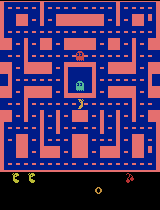

Episode 1901/2500 | score 1920 | recent mean 1832.0 | exploration 10%


Episode 1902/2500 | score 4050 | recent mean 1864.0 | exploration 10%


Episode 1903/2500 | score 1130 | recent mean 1849.6 | exploration 10%


Progress | 1903/2500 complete games | 1,480,000 decisions | 367,501 updates | 116.3 min


Episode 1904/2500 | score 1480 | recent mean 1807.6 | exploration 10%


...

Progress | 1922/2500 complete games | 1,495,000 decisions | 371,251 updates | 117.3 min


Episode 1923/2500 | score 1180 | recent mean 1595.2 | exploration 10%


Episode 1924/2500 | score 970 | recent mean 1543.6 | exploration 10%


Episode 1925/2500 | score 2610 | recent mean 1565.6 | exploration 10%


Separate demonstration score: 1280.0
After 1925 training games | 4× playback | 2 plays | first 20s of game time


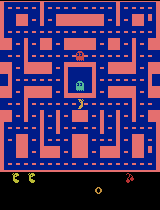

Episode 1926/2500 | score 1360 | recent mean 1543.2 | exploration 10%


Episode 1927/2500 | score 1150 | recent mean 1427.2 | exploration 10%


Episode 1928/2500 | score 1090 | recent mean 1425.6 | exploration 10%


Episode 1929/2500 | score 1000 | recent mean 1406.4 | exploration 10%


Episode 1930/2500 | score 3650 | recent mean 1520.8 | exploration 10%


...

Episode 1948/2500 | score 3610 | recent mean 1925.2 | exploration 10%


Progress | 1948/2500 complete games | 1,515,000 decisions | 376,251 updates | 118.6 min


Episode 1949/2500 | score 1220 | recent mean 1935.2 | exploration 10%


Episode 1950/2500 | score 840 | recent mean 1864.4 | exploration 10%


Separate demonstration score: 2950.0
After 1950 training games | 4× playback | 2 plays | first 20s of game time


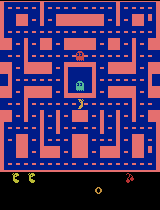

Episode 1951/2500 | score 910 | recent mean 1846.4 | exploration 10%


Episode 1952/2500 | score 1010 | recent mean 1840.8 | exploration 10%


Episode 1953/2500 | score 1280 | recent mean 1848.4 | exploration 10%


Episode 1954/2500 | score 2200 | recent mean 1896.4 | exploration 10%


Progress | 1954/2500 complete games | 1,520,000 decisions | 377,501 updates | 119.0 min


...

Episode 1973/2500 | score 2490 | recent mean 1841.2 | exploration 10%


Progress | 1973/2500 complete games | 1,535,000 decisions | 381,251 updates | 120.0 min


Episode 1974/2500 | score 1660 | recent mean 1858.8 | exploration 10%


Episode 1975/2500 | score 2000 | recent mean 1905.2 | exploration 10%


Separate demonstration score: 840.0
After 1975 training games | 4× playback | 2 plays | first 20s of game time


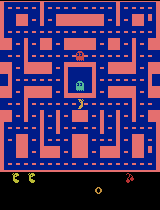

Two-hour wall-clock training cap reached. Saving and evaluating.


Validation candidate after 1975 additional games (final candidate)...


Validation scores [1400.0, 910.0, 3680.0, 1380.0, 1480.0, 2640.0, 1390.0, 530.0, 1840.0, 1080.0] | mean 1633.0 | selection metric 1200.2 | new selected model: False


Saving local learner snapshot (optimizer, target, replay and random states)...


Saved learner snapshot; final evaluation follows.


Saved: pacman_runs/20260921_005003_092029


In [25]:
if _training_started:
    raise RuntimeError("This run already started; rerun from section 5a for a new experiment.")
_training_started = True
started, active_started = time.time(), time.monotonic()
status = "completed"
train_envs = []
try:
    assess_candidate(0, "inherited starting model")
    for slot in range(NUM_TRAIN_ENVS):
        train_envs.append(make_env())
        training_states.append(start_training_game(train_envs[-1], slot))
    train_batched_games(train_envs)
except TrainingBudgetReached:
    status = "time_budget"
    print("Two-hour wall-clock training cap reached. Saving and evaluating.", flush=True)
except KeyboardInterrupt:
    status = "interrupted"
    print("Interrupted once. Saving and evaluating the actual completed training.", flush=True)
except Exception:
    status = "failed"
    raise
finally:
    for env in train_envs:
        env.close()
    save_training_result(status)
print("Saved:", RUN_DIR)
if updates == 0:
    print("No learning updates occurred: this is a setup or failed run.")


## 6. evaluate the independently selected model

Reload the model selected using separate validation games, then compare all five
classroom games under the unchanged settings. The highlighted GIF is the best of
these five games, not the evidence by itself. Five games remain a small comparison.


### 6a. play the saved agent

Reload the checkpoint and play the same five evaluation seeds. This tests both the saved file and the agent’s behavior.

In [26]:
# Load the validation-selected saved model; classroom scores never select it.
checkpoint = torch.load(RUN_DIR / "trained.pt", map_location="cpu", weights_only=True)
trained_model = DQN(checkpoint["n_actions"]).to(DEVICE)
trained_model.load_state_dict(checkpoint["model"])
print("Evaluating the saved trained network on the same five games...", flush=True)
after = evaluate(trained_model, EVAL_SEEDS, RUN_DIR / "demos" / "final_best.gif", record_best=True)

Evaluating the saved trained network on the same five games...


### 6b. compare all five scores

Positive change means a higher average in this small test. A short run can get worse, and one good-looking sample is not enough to claim improvement.

  Game     Before      After
     1        350       2500
     2        500       2120
     3        320       2490
     4        800       2520
     5        490       1130
  Mean      492.0     2152.0
Change in mean score: +1660.0
Time-limited games before / after: 0 / 0


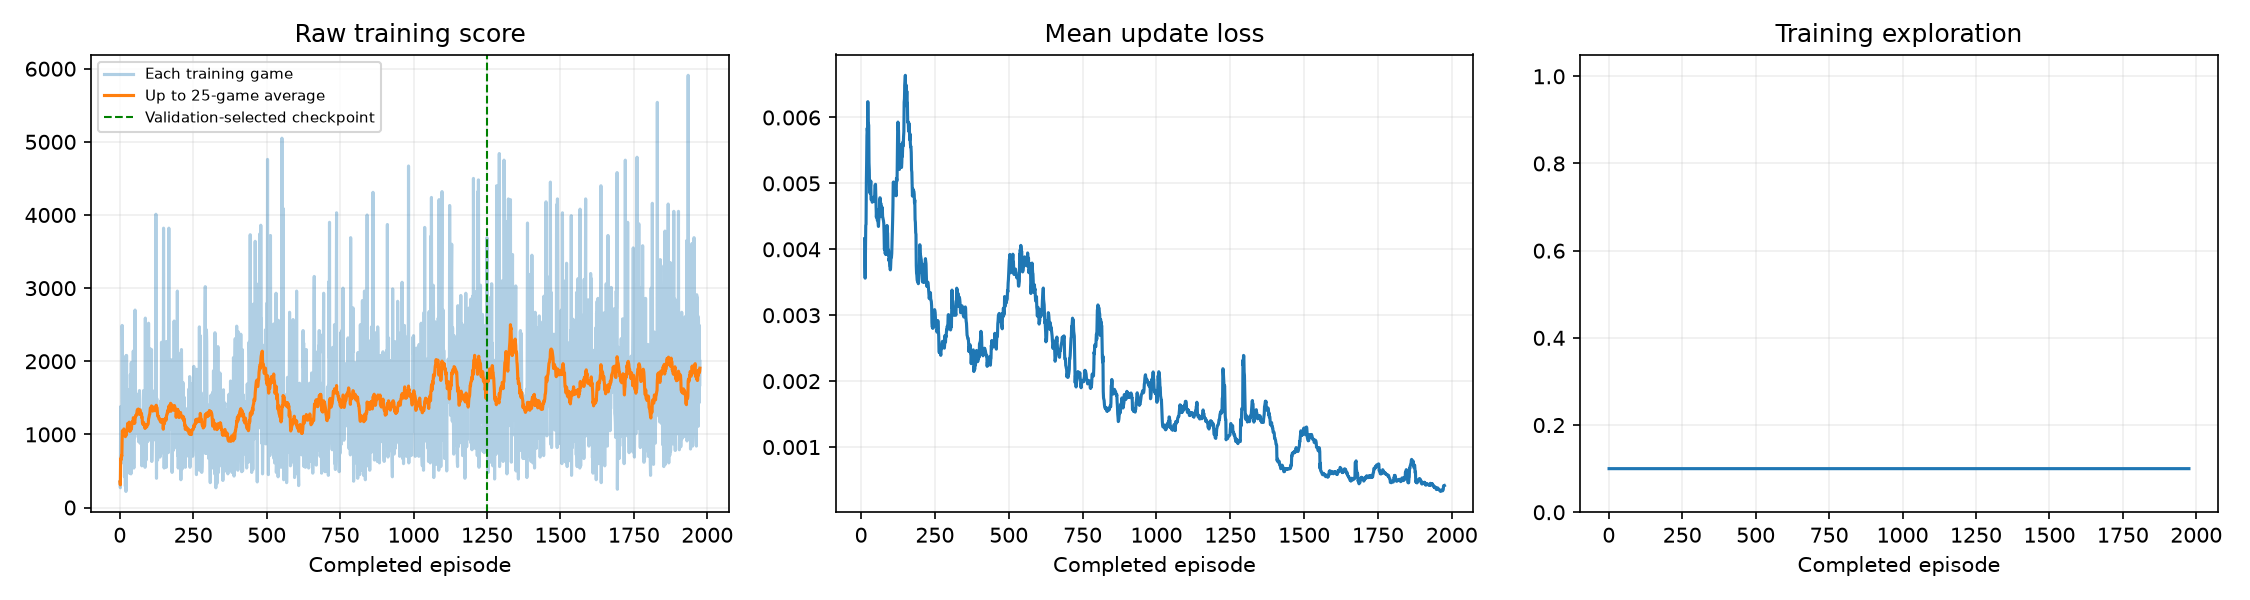

Final saved agent | 4× playback | 2 plays | first 20s of game time


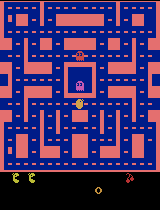

In [27]:
comparison = {"baseline_kind": "untrained network", "before": baseline, "after": after,
              "evaluation_exploration": EVAL_EXPLORATION, "max_decisions_per_game": MAX_STEPS, "warm_start": warm_start_evaluation, "model_selection": "separate validation seeds 20001-20010"}
(RUN_DIR / "comparison.json").write_text(json.dumps(comparison, indent=2))
print(f"{'Game':>6} {'Before':>10} {'After':>10}")
for game, (before_score, after_score) in enumerate(zip(baseline["scores"], after["scores"]), 1):
    print(f"{game:>6} {before_score:>10.0f} {after_score:>10.0f}")
print(f"{'Mean':>6} {baseline['mean']:>10.1f} {after['mean']:>10.1f}")
print(f"Change in mean score: {after['mean'] - baseline['mean']:+.1f}")
print("Time-limited games before / after:", sum(baseline["time_limited"]), "/", sum(after["time_limited"]))
display(Image(filename=str(RUN_DIR / "training_dashboard.png")))
show_sample(RUN_DIR / "demos" / "final_best.gif", "Final saved agent")


## 7. save and explain the experiment

The ZIP preserves settings, all scores, the training log, plots, GIFs, playback
checkpoints, and the large learner snapshot. Keep it locally. The public repository
contains the executed notebook and selected evidence; the starting checkpoint is
available in its linked release. Run All repeats this warm-start experiment, with
fresh replay and optimizer after measuring a genuine untrained baseline.


In [28]:
archive = shutil.make_archive(str(RUN_DIR), "zip", root_dir=RUN_DIR)
try:
    from google.colab import files
except ImportError:
    display(FileLink(archive, result_html_prefix="Download your experiment: "))
else:
    files.download(archive)
print("Results folder:", RUN_DIR.resolve())

/Users/sebastianbardacostaartagaveytia/Documents/ChatGPT/Class 3/pacman_runs/20260921_005003_092029.zip

Results folder: /Users/sebastianbardacostaartagaveytia/Documents/ChatGPT/Class 3/pacman_runs/20260921_005003_092029


### Interpretation and limitations

See README.md for the completed scores and observations from the GIFs. This notebook
retains every executed output. Four game screens are the observations; nine joystick
moves are the actions. Learning uses game points divided by 100, with an extra 0.5
penalty per lost life. Reported evaluation scores always use original game points.

This is a combined engineering experiment, not an isolated causal study. The source
weights already received 1,069 completed training games and 185,875 recorded updates.
Additional training, prioritized replay, three-step targets, and the death penalty
are disclosed separately. Neither lower loss nor the best short GIF proves reliable
3,000-point play. The selected checkpoint is chosen using ten separate validation games, not the
classroom scores. The five official scores and 20 new additional games test the goal.

References: [Rainbow](https://arxiv.org/abs/1710.02298),
[Prioritized Experience Replay](https://arxiv.org/abs/1511.05952), and the
[supplied notebook](https://github.com/pepealonso95/pacman-dqn).
